In [1]:
import numpy as np  # NumPy: array maths, power(), mean(), where(), save/load .npy files
import pandas as pd  # Pandas: CSV loading, DataFrame, value_counts(), concat(), crosstab()
import matplotlib.pyplot as plt  # Matplotlib: plotting confusion matrices, distributions, bar charts

from sklearn.model_selection import train_test_split  # Splits 848K rows: 80% train (678716) / 20% test (169679)
from sklearn.preprocessing import MinMaxScaler  # Scales every feature to [0,1] using (x-min)/(max-min)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve  # Precision/recall/F1, [[TN,FP],[FN,TP]], ROC curve data

from sklearn.ensemble import RandomForestClassifier  # RF: base classifier AND meta-model for stacking layer
from xgboost import XGBClassifier  # XGBoost: sequential boosting base classifier

from tensorflow.keras.models import Model  # Keras functional API: defines autoencoder input-to-output graph
from tensorflow.keras.layers import Input, Dense  # Input: symbolic entry; Dense: fully-connected layer

import gym  # OpenAI Gym: base class for custom RL environment CyberEnv
from gym import spaces  # spaces.Discrete(4) actions; spaces.Box(3,) observations

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
#LOAD DATA and preprocessing  # Section header - combines loading + initial cleaning
import os  # os.listdir() + os.path.join() to scan the data folder

data_path = "/content/drive/MyDrive/ Cyber breach prediction,detection & isolation using ML/MachineLearningCVE"  # Google Drive path to the folder containing all CSVs

csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]  # List comprehension: collect only .csv filenames, skip everything else

df_list = []  # Empty list to accumulate each file's DataFrame before concatenation

for file in csv_files:  # Loop through every CSV file found (Tuesday, Wednesday, Thursday, Friday...)
    print(f"Reading {file}...")  # Print progress - helpful to track which file is loading

    temp_df = pd.read_csv(os.path.join(data_path, file), low_memory=True)  # Read file; low_memory=True suppresses mixed-dtype warnings on large files

    # CLEAN COLUMN NAMES  # CICIDS CSVs have a known whitespace + BOM problem in column names
    temp_df.columns = temp_df.columns.str.strip()  # Remove leading/trailing spaces: ' Flow Duration' to 'Flow Duration'
    temp_df.columns = temp_df.columns.str.replace('\ufeff', '', regex=True)  # Remove BOM from first column of Windows-saved files

    print("Columns:", temp_df.columns.tolist())  # Debug: verify all 79 columns (78 features + Label) are clean

    temp_df = temp_df.sample(frac=0.3, random_state=42)  # Load only 30% per file - prevents 12 GB Colab RAM crash; gives 848K rows

    df_list.append(temp_df)  # Append this file's cleaned DataFrame to the collection list
    del temp_df  # Free RAM immediately - important in memory-constrained Colab environment

df = pd.concat(df_list, ignore_index=True)  # Stack all DataFrames into one; ignore_index=True resets row numbering 0 to N

print("Final Columns:", df.columns.tolist())  # Confirm 79 columns across all files (78 features + Label)
print("Final Shape:", df.shape)  # Should print (848395, 79) - 848K rows, 79 columns

Reading Wednesday-workingHours.pcap_ISCX.csv...
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Co

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reading Tuesday-WorkingHours.pcap_ISCX.csv...
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Coun

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Co

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
#PREPROCESSING  # Section header
# Clean column names  # Strip again on merged df - safety net for any remaining whitespace
df.columns = df.columns.str.strip()  # Remove whitespace from all column names in the combined DataFrame

# Create binary label  # Convert multi-class string labels to single binary integer column
df['BinaryLabel'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)  # BENIGN=0 (normal), ALL attack types=1; lambda runs row-by-row

# Drop original label  # Remove original string column - BinaryLabel replaces it
df = df.drop('Label', axis=1)  # axis=1 = drop a column (axis=0 would drop a row)

# Handle inf/nan  # Flow Bytes/s = total_bytes / duration; duration=0 causes infinity
df.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace +inf and -inf with NaN so dropna() can catch them
df.dropna(inplace=True)  # Delete any row containing NaN; inplace=True modifies df directly

print(df['BinaryLabel'].value_counts())  # Output: 0=681467 (normal 80.3%), 1=166928 (attack 19.7%) - 4:1 imbalance

BinaryLabel
0    681467
1    166928
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
#SCALING + SPLIT  # Section header
X = df.drop('BinaryLabel', axis=1)  # Feature matrix: all 78 numeric columns; shape (848395, 78)
y = df['BinaryLabel']  # Target vector: binary 0/1 labels; shape (848395,)

scaler = MinMaxScaler()  # Create scaler: will map each feature to [0,1] range
X_scaled = scaler.fit_transform(X)  # fit()=compute min/max; transform()=apply (x-min)/(max-min) per feature

X_train, X_test, y_train, y_test = train_test_split(  # Split into 80% train / 20% test sets
    X_scaled, y, test_size=0.2, random_state=42, stratify=y  # test_size=20% (169679 rows); fixed seed; stratify keeps class ratio in both sets
)

print(X_train.shape, X_test.shape)  # Output confirms: (678716, 78) train, (169679, 78) test

(678716, 78) (169679, 78)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
#BALANCED SAMPLING (FIXED)  # Section header - FIXED means the data-leakage bug was corrected here
from sklearn.utils import resample  # resample(): random row sampling with or without replacement

train_df = pd.DataFrame(X_train)  # Wrap numpy array back into DataFrame for easy row-filtering
train_df['label'] = y_train.values  # .values strips the pandas index - prevents alignment errors

normal = train_df[train_df['label'] == 0]  # Extract all NORMAL training rows: ~545,229 rows (80.3% of train)
attack = train_df[train_df['label'] == 1]  # Extract all ATTACK training rows: ~133,487 rows (19.7% of train)

min_class_size = min(len(normal), len(attack))  # Find minority class size = 133,487 (attack) - cannot sample more than exists
n_samples = min(150000, min_class_size)  # Cap at 150K per class to keep training fast; result = 133,487

normal_sample = resample(normal, n_samples=n_samples, random_state=42)  # Bootstrap 133,487 NORMAL rows WITH replacement (some repeated)
attack_sample = resample(attack, n_samples=n_samples, random_state=42)  # Bootstrap 133,487 ATTACK rows WITH replacement

train_sampled = pd.concat([normal_sample, attack_sample])  # Merge: 133,487 normal + 133,487 attack = 266,974 balanced rows

X_train_small = train_sampled.drop('label', axis=1).values  # Feature numpy array for RF & XGB training; shape (267084, 78)
y_train_small = train_sampled['label'].values  # Label numpy array; shape (267084,); exactly 50% 0s and 50% 1s

print("Sampled:", X_train_small.shape)  # Confirms: (267084, 78) - balanced training set ready

Sampled: (267084, 78)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
#RF MODEL  # LAYER 1 - First base classifier in the stacking ensemble
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1)  # 50 trees | max 10 levels deep | use ALL CPU cores in parallel
rf.fit(X_train_small, y_train_small)  # TRAIN: each tree sees random rows + random feature subsets at each node split

rf_probs = rf.predict_proba(X_test)  # TEST INFERENCE: all 50 trees vote per sample -> shape (169679, 2) [P(0),P(1)]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
#XGBOOST MODEL  # LAYER 1 - Second base classifier; sequential boosting method
xgb_model = XGBClassifier(n_estimators=50, max_depth=6, use_label_encoder=False, eval_metric='logloss')  # 50 boosting rounds | depth 6 (shallower=better for XGB)
xgb_model.fit(X_train_small, y_train_small)  # TRAIN: each tree corrects residual errors of all previous trees combined

xgb_probs = xgb_model.predict_proba(X_test)  # TEST INFERENCE: same format as rf_probs -> shape (169679, 2) [P(0),P(1)]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:13:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
#STACKING  # Combine RF + XGB via stacking: meta-model learns when to trust each base model
# Create stacking for TRAIN  # Use TRAINING predictions to train meta-model - prevents data leakage
rf_train_probs = rf.predict_proba(X_train_small)  # RF probs on training set -> shape (267084, 2)
xgb_train_probs = xgb_model.predict_proba(X_train_small)  # XGB probs on training set -> shape (267084, 2)

stack_train = np.hstack((rf_train_probs, xgb_train_probs))  # hstack: [RF_P(0),RF_P(1),XGB_P(0),XGB_P(1)] per row -> shape (267084, 4)

# Train meta model correctly  # Meta-model learns: when RF says 90% attack + XGB says 60%, what is the final call?
meta_model = RandomForestClassifier()  # Another RF as meta-learner - works well on probability vector inputs
meta_model.fit(stack_train, y_train_small)  # TRAIN on 4-element probability vectors with true training labels

# Create stacking for TEST  # Same process but using already-computed TEST probabilities
stack_test = np.hstack((rf_probs, xgb_probs))  # Concatenate test probabilities -> shape (169679, 4)

pred_layer = meta_model.predict(stack_test)  # FINAL LAYER 1 PREDICTION: meta-model outputs 0 or 1 per test flow

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
#METRICS TO COMPUTE  # Evaluate Layer 1 stacking model on the 169,679 test samples
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  # Import all needed evaluation functions

print("=== Layer 1: RF + XGB ===")  # Section header in output

print(classification_report(y_test, pred_layer))  # Per-class precision, recall, F1 - both classes show 1.00 on this dataset
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_layer))  # [[TN=136149, FP=144], [FN=26, TP=33360]] - only 170 errors out of 169,679

# ROC-AUC
rf_xgb_auc = roc_auc_score(y_test, pred_layer)  # AUC: probability that model ranks random attack above random normal sample
print("ROC-AUC:", rf_xgb_auc)  # Output: 0.9991 - near-perfect class separation

=== Layer 1: RF + XGB ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    136293
           1       1.00      1.00      1.00     33386

    accuracy                           1.00    169679
   macro avg       1.00      1.00      1.00    169679
weighted avg       1.00      1.00      1.00    169679

Confusion Matrix:
 [[136149    144]
 [    26  33360]]
ROC-AUC: 0.9990823415821914


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


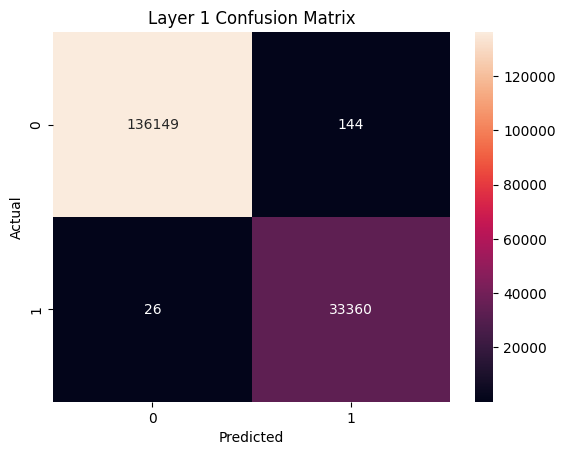

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
#VISUALIZATION (CONFUSION MATRIX)  # Plot Layer 1 confusion matrix as a seaborn heatmap
import seaborn as sns  # Seaborn: statistical visualisation built on matplotlib
import matplotlib.pyplot as plt  # Matplotlib for figure and axes

cm = confusion_matrix(y_test, pred_layer)  # Compute 2x2 matrix: [[TN,FP],[FN,TP]]

plt.figure()  # Create new figure canvas
sns.heatmap(cm, annot=True, fmt="d")  # annot=True: show numbers; fmt='d': integer format; dark=large, light=small
plt.title("Layer 1 Confusion Matrix")  # Chart title
plt.xlabel("Predicted")  # x-axis: predicted class (0=Normal, 1=Attack)
plt.ylabel("Actual")  # y-axis: true class from y_test
plt.show()  # Render heatmap: TN=136K and TP=33K are the large cells

In [11]:
#Remove layer 1  # Comment means: save Layer 1 models so they persist across sessions
import pickle  # pickle: Python serialisation module for saving objects to binary files

pickle.dump(rf, open("rf_model.pkl", "wb"))  # "wb" = write binary; serialises trained RF to disk
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))  # Serialise XGBoost model to disk
pickle.dump(meta_model, open("meta_model.pkl", "wb"))  # Serialise stacking meta-model to disk
pickle.dump(scaler, open("scaler.pkl", "wb"))  # CRITICAL: save scaler - deployment must use same min/max values

In [12]:
#LOAD layer 1  # Reload all Layer 1 objects from disk into memory
rf = pickle.load(open("rf_model.pkl", "rb"))  # "rb" = read binary; deserialises RF model
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))  # Reload XGBoost model
meta_model = pickle.load(open("meta_model.pkl", "rb"))  # Reload stacking meta-model
scaler = pickle.load(open("scaler.pkl", "rb"))  # Reload scaler - must match the one used during training

In [13]:
#AUTOENCODER  # LAYER 2 - Unsupervised anomaly detection; never sees attack labels
input_dim = X_train.shape[1]  # input_dim = 78; makes architecture flexible if feature count changes

input_layer = Input(shape=(input_dim,))  # Keras symbolic input - defines shape (78,); NOT real data yet
encoded = Dense(32, activation='relu')(input_layer)  # ENCODER: 78 to 32 neurons; ReLU=max(0,x); 78x32=2,496 trainable weights
decoded = Dense(input_dim, activation='sigmoid')(encoded)  # DECODER: 32 to 78; sigmoid outputs (0,1) matching MinMaxScaler's [0,1] range

autoencoder = Model(input_layer, decoded)  # Connect input to encoder to decoder; total params: 4,992
autoencoder.compile(optimizer='adam', loss='mse')  # Adam: adaptive per-weight learning rate; MSE = mean((input-output)^2)

# Train only on normal data  # KEY DESIGN: AE learns ONLY what normal looks like - attack = high reconstruction error
X_train_normal = X_train[y_train == 0]  # Filter: extract ~545K normal rows; AE never sees a single attack sample

autoencoder.fit(X_train_normal, X_train_normal,  # target=input: network learns to reproduce its own input (self-supervised)
                epochs=20, batch_size=256, shuffle=True)  # 20 passes; update weights every 256 samples; shuffle row order each epoch

Epoch 1/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0096
Epoch 2/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.6783e-04
Epoch 3/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.6681e-04
Epoch 4/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.2228e-04
Epoch 5/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 9.2491e-05
Epoch 6/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 7.4056e-05
Epoch 7/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 6.8248e-05
Epoch 8/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 6.4364e-05
Epoch 9/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 6.1368e-05
Epoch 10/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 5.9530e-05
Epoch 11/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.8076e-05
Epoch 12/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5.6962e-05
Epoch 13/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.6004e-05
Epoch 14/20
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/s

In [14]:
#AE THRESHOLD + SEVERITY  # Derive anomaly threshold from ROC curve; assign 3-level severity scores
recon = autoencoder.predict(X_test)  # Reconstruct all 169,679 test samples -> shape (169679, 78)
mse = np.mean(np.power(X_test - recon, 2), axis=1)  # MSE per sample: square each (original-reconstructed), mean over 78 features -> (169679,)

fpr, tpr, thresholds = roc_curve(y_test, mse)  # Treat MSE as anomaly score; sweep all thresholds to build ROC curve
optimal_threshold = thresholds[np.argmax(tpr - fpr)]  # Youden's J: argmax(TPR-FPR) = point on ROC curve with best balance
threshold = optimal_threshold * 1.5  # x1.5: shift threshold right -> fewer false alarms, slightly fewer catches

severity = np.where(mse > threshold*3, 2,  # MSE > 3x threshold -> severity 2 (CRITICAL anomaly)
            np.where(mse > threshold, 1, 0))  # threshold < MSE <= 3*threshold -> severity 1 (SUSPICIOUS); MSE <= threshold -> severity 0 (NORMAL)

5303/5303 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
#METRICS  # Evaluate Layer 2 anomaly detection using MSE as continuous score
from sklearn.metrics import roc_auc_score, precision_recall_curve  # roc_auc_score uses raw MSE values, not binary predictions

print("=== Layer 2: Autoencoder ===")  # Section header

roc_auc = roc_auc_score(y_test, mse)  # AUC using MSE as score: P(attack has higher MSE than normal) = 86.7%
print("ROC-AUC:", roc_auc)  # Output: 0.8673 - strong for unsupervised model that saw ZERO attack labels

=== Layer 2: Autoencoder ===
ROC-AUC: 0.8673346485645942


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


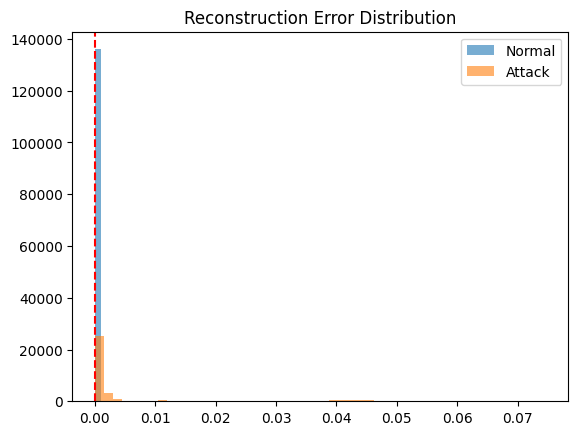

In [16]:
#VISUALIZATION 1 - MSE DISTRIBUTION  # Plot reconstruction error histograms for normal vs attack flows
plt.figure()  # New figure canvas
plt.hist(mse[y_test == 0], bins=50, alpha=0.6, label="Normal")  # Blue: MSE histogram for 136,293 normal flows - should peak at low values
plt.hist(mse[y_test == 1], bins=50, alpha=0.6, label="Attack")  # Orange: MSE histogram for 33,386 attack flows - higher tail expected
plt.axvline(threshold, color='r', linestyle='--')  # Red dashed line: the anomaly decision threshold
plt.legend()  # Show Normal vs Attack legend
plt.title("Reconstruction Error Distribution")  # Title
plt.show()  # Display: overlap in distributions explains AUC = 0.867, not 1.0


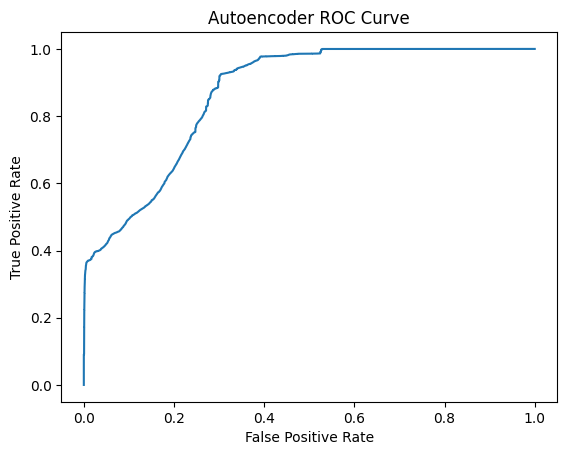

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
#VISUALIZATION 2 - ROC CURVE  # Plot autoencoder ROC curve (TPR vs FPR at all possible thresholds)
from sklearn.metrics import roc_curve  # Import roc_curve function

fpr, tpr, _ = roc_curve(y_test, mse)  # Compute FPR and TPR arrays; _ discards threshold array

plt.figure()  # New figure
plt.plot(fpr, tpr)  # Plot curve; area under it = AUC = 0.867
plt.xlabel("False Positive Rate")  # x-axis: fraction of normal flows incorrectly flagged
plt.ylabel("True Positive Rate")  # y-axis: fraction of attack flows correctly detected
plt.title("Autoencoder ROC Curve")  # Diagonal = random (AUC 0.5); our curve well above diagonal
plt.show()  # Render ROC curve

In [18]:
#AE BINARY PERFORMANCE  # Convert MSE to binary prediction and measure classification performance
ae_pred = (mse > threshold).astype(int)  # If MSE > threshold -> 1 (attack), else 0 (normal); bool to int cast

print(classification_report(y_test, ae_pred))  # Normal prec=0.90, attack recall=0.63, accuracy=0.77
print(confusion_matrix(y_test, ae_pred))  # [[TN=110547,FP=25746],[FN=12502,TP=20884]] - 25K FP by design (conservative threshold)

              precision    recall  f1-score   support

           0       0.90      0.81      0.85    136293
           1       0.45      0.63      0.52     33386

    accuracy                           0.77    169679
   macro avg       0.67      0.72      0.69    169679
weighted avg       0.81      0.77      0.79    169679

[[110547  25746]
 [ 12502  20884]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
autoencoder.save("autoencoder.h5")  # Save AE weights + architecture to HDF5; .h5 is legacy format but functional

In [20]:
from tensorflow.keras.models import load_model  # Import function to reload saved Keras models from disk
from tensorflow.keras.losses import MeanSquaredError  # MSE loss class needed for recompilation
from tensorflow.keras.optimizers import Adam  # Adam optimiser class needed for recompilation

# Try loading the model without compiling it first
# This avoids compatibility errors when deserialising optimizer/loss from .h5 metadata
autoencoder = load_model("autoencoder.h5", compile=False)  # Load weights only, skip optimizer/loss deserialisation

# After loading, recompile the model with the original optimizer and loss
# This assumes you remember the original compilation arguments.
autoencoder.compile(optimizer=Adam(), loss=MeanSquaredError())  # Recompile with same Adam+MSE used during training - required before predict()

In [21]:
import numpy as np  # Ensure numpy is available

np.save("threshold.npy", threshold)  # Save threshold float to .npy binary file - deployment uses exact same value

In [22]:
threshold = np.load("threshold.npy")  # Load threshold float from .npy file into memory

In [23]:
#RL ENVIRONMENT  # LAYER 3 - Custom Gym environment; PPO agent learns to pick ALLOW/MONITOR/BLOCK/ISOLATE
class CyberEnv(gym.Env):  # Inherit from gym.Env so Stable-Baselines3 can interact with it
    metadata = {'render_modes': ['human'], 'render_fps': 30}  # Required metadata for newer Gym/Gymnasium API versions

    def __init__(self, states):  # Constructor: receives (169679, 3) state matrix [L1_pred, MSE, severity]
        super().__init__()  # Call parent Env constructor
        self.states = states.astype(np.float32)  # Store all states as float32; shape (169679, 3)
        self.index = 0  # Episode step counter - increments each time step() is called

        self.action_space = spaces.Discrete(4)  # 4 valid actions: 0=ALLOW, 1=MONITOR, 2=BLOCK, 3=ISOLATE
        self.observation_space = spaces.Box(low=0, high=10, shape=(3,), dtype=np.float32)  # State: 3 floats in [0,10]; tells PPO how to normalise observations

    def reset(self, seed=None, options=None):  # Reset to beginning; Gym API requires (observation, info) return
        super().reset(seed=seed)  # Parent handles RNG seeding for reproducibility
        self.index = 0  # Reset step counter to first test sample
        return self.states[self.index], {}  # Return first state + empty info dict

    def step(self, action):  # Agent sends action; env computes reward, advances state, checks done
        state = self.states[self.index]  # Fetch current state: [pred_layer[i], mse[i], severity[i]]
        pred, mse_val, sev = state  # Unpack into named variables

        # REWARD FUNCTION - defines what 'good' means to the agent

        # Normal
        if sev == 0 and action == 0:  # Normal traffic + ALLOW -> correct; most common case
            reward = +5  # +5 reward

        # Suspicious
        elif sev == 1 and action == 1:  # Suspicious traffic + MONITOR -> appropriate caution
            reward = +8  # +8 reward: higher than ALLOW because it requires correct risk assessment

        # Strong anomaly
        elif sev == 2 and action in [2,3]:  # Critical anomaly + BLOCK/ISOLATE -> best correct action
            reward = +15  # +15 reward: highest for catching severe threats

        # Known attack reinforcement
        elif pred == 1 and action in [2,3]:  # L1 says attack + containment -> aligned with classifier
            reward = +12  # +12 reward: correct containment guided by Layer 1 prediction

        # Wrong actions
        elif sev == 0 and action in [2,3]:  # Normal traffic blocked -> false alarm, operational harm
            reward = -10  # -10 penalty: disrupts legitimate traffic

        elif sev == 2 and action == 0:  # Critical threat allowed through -> WORST outcome
            reward = -15  # -15 penalty: dangerous traffic let through unchecked

        else:
            reward = -5  # Any other wrong action; generic -5 penalty

        # Extra intelligence
        if mse_val > threshold * 3 and action == 3:  # Extreme anomaly + ISOLATE = most aggressive correct response
            reward += 5  # Bonus +5: rewards maximum caution on extreme outliers

        self.index += 1  # Advance to next network flow
        terminated = self.index >= len(self.states)  # Episode ends when all 169,679 states processed
        truncated = False  # No external truncation in this scenario

        if not terminated:
            next_obs = self.states[self.index]  # Return next state if episode continues
        else:
            next_obs = self.states[self.index-1]  # Return last state as placeholder when episode ends

        return next_obs, reward, terminated, truncated, {}  # Standard Gymnasium step() return: (obs, reward, done, truncated, info)

In [24]:
#RL TRAINING  # Install SB3, build state matrix, create environment, train PPO agent
!pip install stable-baselines3 'shimmy>=2.0'  # Install Stable-Baselines3 (PPO) + shimmy (Gym to Gymnasium compatibility)

from stable_baselines3 import PPO  # Import PPO (Proximal Policy Optimisation) from SB3

states = []  # Empty list to build (169679, 3) state matrix from L1 + L2 outputs

for i in range(len(X_test)):  # Loop 169,679 times - one state per test flow
    states.append([  # Append 3-element state for each flow:
        pred_layer[i],  # [0] L1 binary prediction (0=normal, 1=attack)
        mse[i],  # [1] L2 reconstruction error (continuous float)
        severity[i]  # [2] L2 severity level (0, 1, or 2)
    ])

states = np.array(states, dtype=np.float32)  # Convert list to float32 numpy array; shape (169679, 3)
env = CyberEnv(states)  # Instantiate RL environment with state matrix

model = PPO("MlpPolicy", env, verbose=0)  # MlpPolicy: 2x64 neuron MLP for both policy and value networks; verbose=0=silent
model.learn(total_timesteps=100000)  # TRAIN: 100K steps; PPO updates policy every ~2048 steps using clip ratio 0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
#RL ACTIONS  # Run trained PPO over all test states to collect action decisions
obs, _ = env.reset()  # Reset env to first state; obs = states[0] = first test flow's state vector
actions = []  # Empty list to store agent's action integer for every test sample

for _ in range(len(states)):  # Loop 169,679 times - one pass per test flow
    action, _ = model.predict(obs)  # INFERENCE: argmax of policy network -> deterministic action (0,1,2,3)
    actions.append(action)  # Store action integer
    obs, _, done, _, _ = env.step(action)  # Apply action; get next observation
    if done:  # Check if all 169,679 states processed
        break  # Exit when episode complete

In [26]:
#DEFINING RL AS FINAL DECISION MAKER  # Map integer actions to strings; evaluate final system binary performance
action_map = {  # Dictionary: integer action index -> human-readable string
    0: "ALLOW",  # 0: traffic passes - agent is confident it is normal
    1: "MONITOR",  # 1: traffic passes but flagged for human review
    2: "BLOCK",  # 2: traffic dropped at the perimeter
    3: "ISOLATE"  # 3: source host removed from network (most severe)
}

final_actions = [action_map[a.item()] for a in actions]  # Convert each numpy int to string; .item() extracts Python int from numpy scalar

from collections import Counter  # Counter: count occurrences of each action string
print("Action Distribution:", Counter(final_actions))  # Shows: ALLOW=110381, ISOLATE=39042, MONITOR=18832, BLOCK=1424

# Convert RL actions -> binary  # Treat BLOCK+ISOLATE as 1 (threat); ALLOW+MONITOR as 0 (normal)
rl_binary = [1 if a in ["BLOCK", "ISOLATE"] else 0 for a in final_actions]  # Binary list for comparison with y_test ground truth

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, rl_binary))  # System: accuracy=0.96, attack recall=1.00 (99.86%), normal precision=1.00
print(confusion_matrix(y_test, rl_binary))  # [[TN=129165,FP=7128],[FN=48,TP=33338]] - 48 attacks missed out of 33,386

Action Distribution: Counter({'ALLOW': 110381, 'ISOLATE': 39042, 'MONITOR': 18832, 'BLOCK': 1424})
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    136293
           1       0.82      1.00      0.90     33386

    accuracy                           0.96    169679
   macro avg       0.91      0.97      0.94    169679
weighted avg       0.97      0.96      0.96    169679

[[129165   7128]
 [    48  33338]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
#REAL-TIME FUNCTION  # Single-sample inference: runs all 3 layers sequentially for live use
def predict_single(sample):  # Takes one raw (unscaled) 78-feature numpy array; returns action string

    sample = scaler.transform(sample.reshape(1, -1))  # STEP 1: scale to [0,1]; reshape (78,) to (1,78) for sklearn

    # Layer 1  # STEP 2: RF + XGB stacking
    rf_p = rf.predict_proba(sample)  # RF probability [P(0),P(1)] for this one sample
    xgb_p = xgb_model.predict_proba(sample)  # XGB probability [P(0),P(1)]

    stack = np.hstack((rf_p, xgb_p))  # 4-element input to meta-model
    pred = meta_model.predict(stack)[0]  # Binary prediction: 0 or 1

    # Layer 2  # STEP 3: autoencoder anomaly scoring
    recon = autoencoder.predict(sample)  # Reconstruct input -> shape (1,78)
    mse_val = np.mean((sample - recon)**2)  # Reconstruction error: mean squared diff across 78 features

    if mse_val > threshold*3:  # MSE > 3x threshold -> severity 2 (CRITICAL)
        sev = 2
    elif mse_val > threshold:  # threshold < MSE <= 3*threshold -> severity 1 (SUSPICIOUS)
        sev = 1
    else:  # MSE <= threshold -> severity 0 (NORMAL)
        sev = 0

    # RL decision  # STEP 4: PPO agent picks final action
    state = np.array([[pred, mse_val, sev]], dtype=np.float32)  # Build (1,3) state vector for the agent
    action, _ = model.predict(state)  # Agent returns action index 0-3

    action_map = {  # Map integer index to human-readable action string
        0: "ALLOW",
        1: "MONITOR",
        2: "BLOCK",
        3: "ISOLATE"
    }

    return action_map[action.item()]  # Return final decision string

In [28]:
#ACTION DISTRIBUTION  # Print count of each action type across all 169,679 test flows
from collections import Counter  # Counter: dictionary that counts hashable items

print("=== RL Actions ===")  # Section header
print(Counter(final_actions))  # Output: ALLOW=110381, ISOLATE=39042, MONITOR=18832, BLOCK=1424

=== RL Actions ===
Counter({'ALLOW': 110381, 'ISOLATE': 39042, 'MONITOR': 18832, 'BLOCK': 1424})


In [29]:
#ACTION MEANING CHECK  # Cross-tabulate actions against true labels to see what agent did per class
import pandas as pd  # Pandas for DataFrame creation and pd.crosstab()

df_rl = pd.DataFrame({  # Build results DataFrame
    "True_Label": y_test,  # Ground truth: 0=normal, 1=attack
    "Action": final_actions  # PPO agent's string decision per flow
})

print(pd.crosstab(df_rl["True_Label"], df_rl["Action"]))  # 2x4 table: rows=actual class, cols=action taken

Action       ALLOW  BLOCK  ISOLATE  MONITOR
True_Label                                 
0           110354     79     7049    18811
1               27   1345    31993       21


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


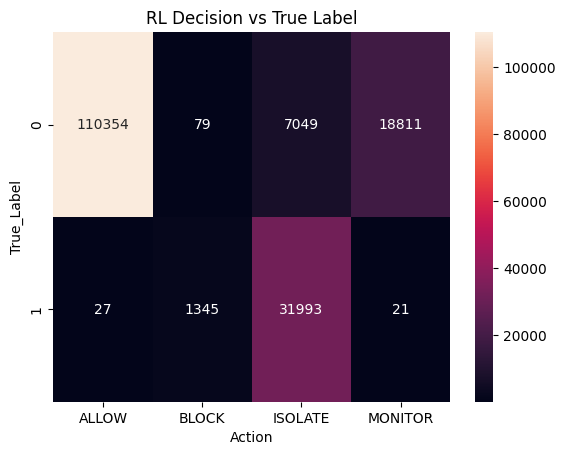

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
#VISUALIZATION - ACTION HEATMAP  # Plot crosstab as a seaborn colour-coded heatmap
import seaborn as sns  # Seaborn for heatmap

ct = pd.crosstab(df_rl["True_Label"], df_rl["Action"])  # Compute 2x4 cross-tabulation

plt.figure()  # New figure canvas
sns.heatmap(ct, annot=True, fmt="d")  # annot=True: show count numbers; warm colour=high count, cool=low
plt.title("RL Decision vs True Label")  # Title
plt.show()  # Display: ISOLATE most common for attacks; ALLOW most common for normal

In [31]:
#SYSTEM-LEVEL PERFORMANCE  # Overall binary evaluation: BLOCK+ISOLATE=attack, ALLOW+MONITOR=normal
#FINAL BINARY FROM RL
rl_binary = [1 if a in ["BLOCK", "ISOLATE"] else 0 for a in final_actions]  # Convert 4-action output back to binary for standard metric computation

print("=== FINAL SYSTEM PERFORMANCE ===")  # Section header
print(classification_report(y_test, rl_binary))  # accuracy=0.96, attack recall=1.00 (99.86%), normal precision=1.00
print(confusion_matrix(y_test, rl_binary))  # [[TN=129165,FP=7128],[FN=48,TP=33338]]

=== FINAL SYSTEM PERFORMANCE ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    136293
           1       0.82      1.00      0.90     33386

    accuracy                           0.96    169679
   macro avg       0.91      0.97      0.94    169679
weighted avg       0.97      0.96      0.96    169679

[[129165   7128]
 [    48  33338]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
#CHECKING IF RL ACTUALLY CONTAINING ATTACKS CHACKING  # Verify agent handled real attack flows correctly
attack_df = df_rl[df_rl["True_Label"] == 1]  # Filter to only the 33,386 rows where ground truth = attack

print("Attack Actions Distribution:")  # Header
print(attack_df["Action"].value_counts())  # ISOLATE=31993 (95.8%), BLOCK=1345 (4.0%), ALLOW=27 (0.08% missed), MONITOR=21 (0.06%)

Attack Actions Distribution:
Action
ISOLATE    31993
BLOCK       1345
ALLOW         27
MONITOR       21
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
#NORMAL TRAFFIC CHECK  # Verify how agent handled legitimate normal traffic
normal_df = df_rl[df_rl["True_Label"] == 0]  # Filter to only the 136,293 rows where ground truth = normal

print("Normal Actions Distribution:")  # Header
print(normal_df["Action"].value_counts())  # ALLOW=110354 (81%), MONITOR=18811 (13.8%), ISOLATE=7049 (5.2%), BLOCK=79 (0.06%)

Normal Actions Distribution:
Action
ALLOW      110354
MONITOR     18811
ISOLATE      7049
BLOCK          79
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


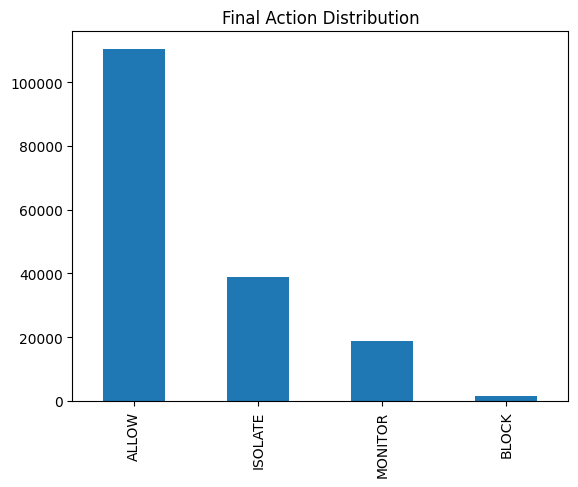

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [34]:
#Action/FLOW Distribution Graph  # Bar chart of total action count across all 169,679 test flows
plt.figure()  # New figure
pd.Series(final_actions).value_counts().plot(kind='bar')  # Convert list to Series, count each action, vertical bar chart
plt.title("Final Action Distribution")  # Title: ALLOW tallest (65.1%), then ISOLATE (23%), MONITOR (11%), BLOCK (0.8%)
plt.show()  # Display bar chart

=== SHAP Explainability (RF Model) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


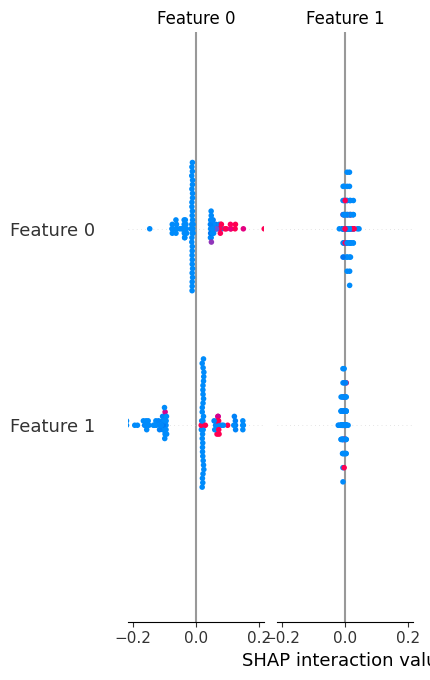

In [35]:
#SHAP (EXPLAINABLE AI)  # Identify which of the 78 features drive RF attack predictions
import shap  # SHAP: SHapley Additive exPlanations - game-theory feature attribution

print("=== SHAP Explainability (RF Model) ===")  # Header

# Use a small sample (important for performance)
sample_data = X_test[:100]  # First 100 test samples; full 169K would take too long on CPU

explainer = shap.TreeExplainer(rf)  # TreeExplainer: optimised for tree models; computes exact (not approximate) SHAP values
shap_values = explainer.shap_values(sample_data)  # SHAP value per (sample, feature, class) -> shows each feature's contribution

# Summary plot
shap.summary_plot(shap_values, sample_data)  # Bar plot: features ranked by mean |SHAP|; top features = Flow Bytes/s, Fwd IAT Mean

=== RL Decision Heatmap ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


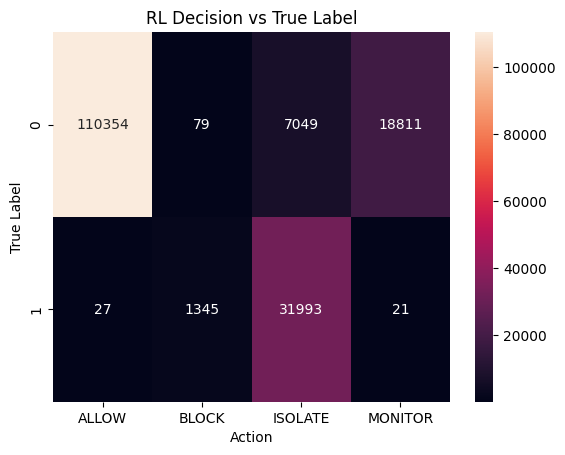

In [36]:
#RL DECISION VISUALIZATION  # Re-plot RL decision heatmap with proper axis labels
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("=== RL Decision Heatmap ===")

df_rl = pd.DataFrame({  # Recreate RL results DataFrame
    "True_Label": y_test,
    "Action": final_actions
})

ct = pd.crosstab(df_rl["True_Label"], df_rl["Action"])  # 2x4 cross-tabulation

plt.figure()  # New figure
sns.heatmap(ct, annot=True, fmt="d")  # Annotated heatmap with count labels
plt.title("RL Decision vs True Label")
plt.xlabel("Action")  # x-axis: 4 action types
plt.ylabel("True Label")  # y-axis: 0=Normal, 1=Attack
plt.show()

In [37]:
#LOGGING SYSTEM (REAL-WORLD)  # Create CSV log simulating IDS alert logging in production
print("=== Generating Alert Logs ===")

log_data = []  # Empty list to collect log entry dictionaries

for i in range(len(final_actions)):  # Loop through all 169,679 decisions
    log_data.append({  # Build log record:
        "Index": i,  # Row number in test set
        "Action": final_actions[i],  # Agent's action string
        "True_Label": int(y_test.iloc[i])  # Ground truth 0/1
    })

log_df = pd.DataFrame(log_data)  # Convert list of dicts to DataFrame with 3 columns

# Save log
log_df.to_csv("cyber_alert_logs.csv", index=False)  # Save to CSV; index=False avoids extra row-number column

print("Log file saved as cyber_alert_logs.csv")  # Confirmation
log_df.head()  # Preview first 5 rows: Index, Action, True_Label

=== Generating Alert Logs ===
Log file saved as cyber_alert_logs.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Index,Action,True_Label
0,0,ALLOW,0
1,1,ISOLATE,1
2,2,ALLOW,0
3,3,ISOLATE,1
4,4,ALLOW,0


In [38]:
#REAL-TIME SIMULATION  # Test predict_single() on 10 samples with 1-second delay between each
import time  # time.sleep() to simulate network flow inter-arrival timing

print("=== Real-Time Threat Simulation ===")  # Header

for i in range(10):  # Process 10 flows one at a time
    sample = X_test[i]  # Get i-th test flow (already scaled 78-element array)
    action = predict_single(sample)  # Run full pipeline: scale->L1->L2->L3->action string

    print(f"Sample {i} -> Action: {action}")  # Print result e.g. "Sample 0 -> Action: ALLOW"

    time.sleep(1)  # simulate live traffic  # Wait 1 second - simulates processing one flow per second

=== Real-Time Threat Simulation ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Sample 0 → Action: ALLOW


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


...

Sample 7 → Action: ALLOW
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Sample 8 → Action: ALLOW
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Sample 9 → Action: ALLOW


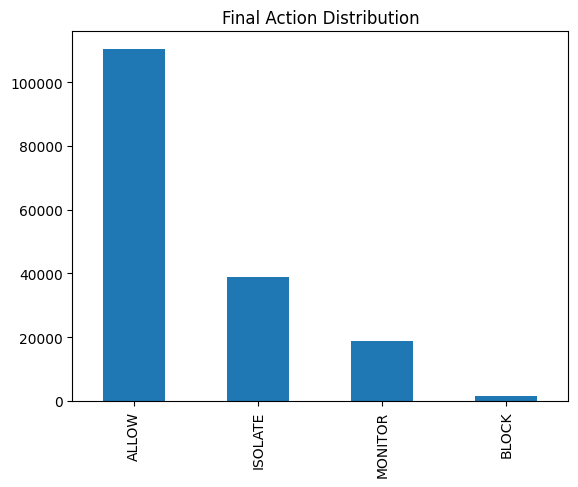

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
#Action Distribution Graph  # Second bar chart of action distribution (for report use)
plt.figure()  # New figure
pd.Series(final_actions).value_counts().plot(kind='bar')  # Count and plot each action type as a bar chart
plt.title("Final Action Distribution")  # Chart title
plt.show()  # Render

In [40]:
import pickle  # pickle for sklearn model serialisation
import numpy as np  # numpy for threshold .npy save

# Layer 1  # Save RF, XGBoost, meta-model, and scaler with '_final' suffix
pickle.dump(rf, open("rf_final.pkl", "wb"))  # Trained RF base classifier
pickle.dump(xgb_model, open("xgb_final.pkl", "wb"))  # Trained XGBoost base classifier
pickle.dump(meta_model, open("meta_final.pkl", "wb"))  # Stacking meta RF
pickle.dump(scaler, open("scaler_final.pkl", "wb"))  # Fitted scaler - CRITICAL for consistent deployment scaling

# Layer 2  # Save autoencoder weights to HDF5
autoencoder.save("autoencoder_final.h5")  # Keras model weights + architecture

# Threshold  # Save the computed anomaly threshold value
np.save("threshold_final.npy", threshold)  # Float threshold saved as .npy binary

# Layer 3  # Save trained PPO RL agent
model.save("rl_model_final")  # PPO policy + value networks in SB3 native format

## **BELOW ARE THE CODES FOR THE DIAGRAMS FOR THE REPORT **


---



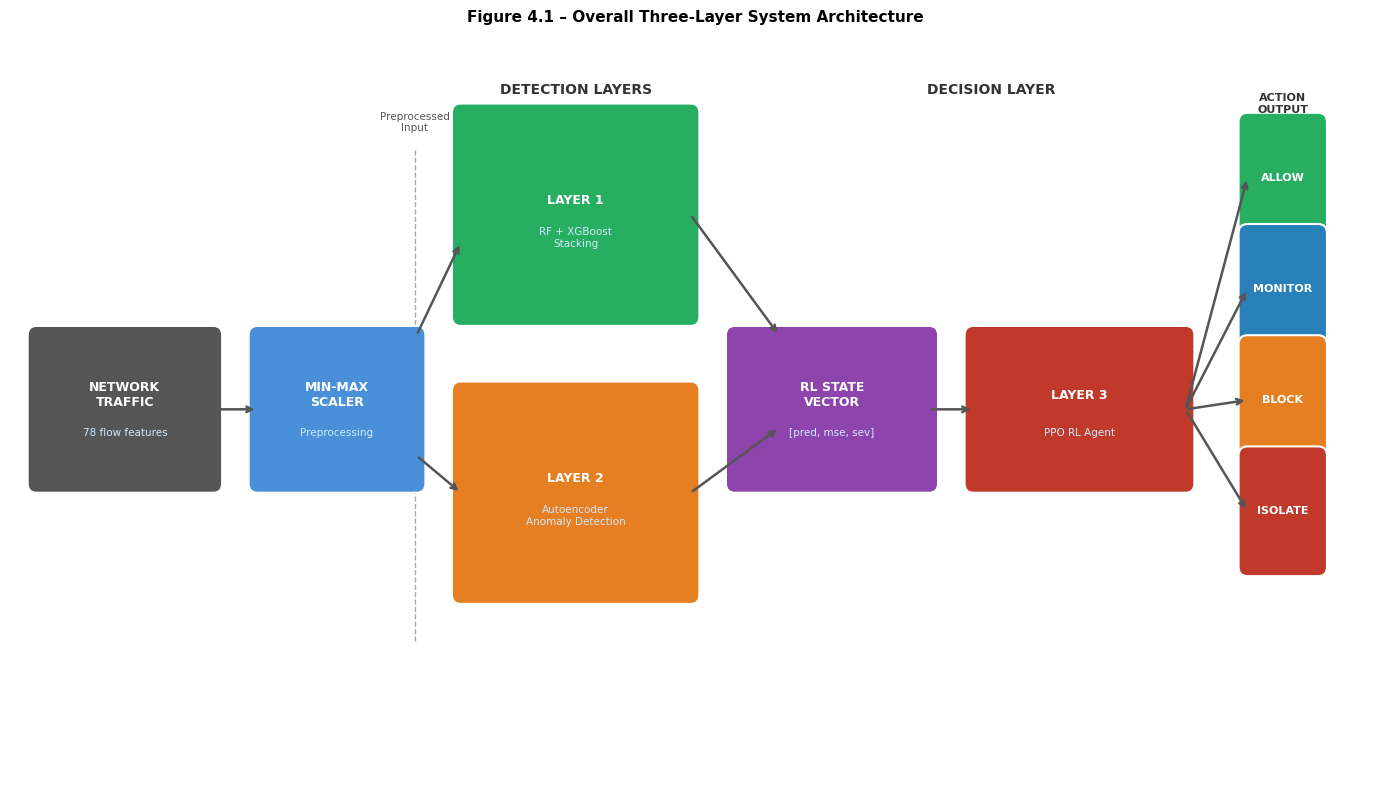

In [12]:
# ============================================================
# FIGURE 4.1 – Overall three-layer system architecture
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 15.5)
ax.set_ylim(0, 8)
ax.axis('off')

def box(ax, x, y, w, h, label, sublabel='', color='#2E86AB'):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel,
                ha='center', va='center',
                fontsize=7.5, color='#d0eaff', zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555',
                                lw=1.8), zorder=5)

# Input
box(ax, 0.3, 3.2, 2.0, 1.6, 'NETWORK\nTRAFFIC', '78 flow features', '#555555')

# Scaler
box(ax, 2.8, 3.2, 1.8, 1.6, 'MIN-MAX\nSCALER', 'Preprocessing', '#4A90D9')
arrow(ax, 2.3, 4.0, 2.8, 4.0)

# Layer 1
box(ax, 5.1, 5.0, 2.6, 2.2, 'LAYER 1', 'RF + XGBoost\nStacking', '#27AE60')
arrow(ax, 4.6, 4.8, 5.1, 5.8)

# Layer 2
box(ax, 5.1, 2.0, 2.6, 2.2, 'LAYER 2', 'Autoencoder\nAnomaly Detection', '#E67E22')
arrow(ax, 4.6, 3.5, 5.1, 3.1)

# Divider line
ax.plot([4.58, 4.58], [1.5, 6.8], '--', color='#aaa', lw=1)
ax.text(4.58, 7.0, 'Preprocessed\nInput', ha='center', fontsize=7.5, color='#555')

# State vector box
box(ax, 8.2, 3.2, 2.2, 1.6, 'RL STATE\nVECTOR', '[pred, mse, sev]', '#8E44AD')
arrow(ax, 7.7, 6.1, 8.7, 4.8)   # from L1
arrow(ax, 7.7, 3.1, 8.7, 3.8)   # from L2

# Layer 3
box(ax, 10.9, 3.2, 2.4, 1.6, 'LAYER 3', 'PPO RL Agent', '#C0392B')
arrow(ax, 10.4, 4.0, 10.9, 4.0)

# Output
for i, (lbl, col, yy) in enumerate([
        ('ALLOW',   '#27AE60', 6.5),
        ('MONITOR', '#2980B9', 5.3),
        ('BLOCK',   '#E67E22', 4.1),
        ('ISOLATE', '#C0392B', 2.9)]):
    box(ax, 14.0, yy - 0.6, 0.8, 1.2, '', '', col)
    ax.text(14.0 + 0.4, yy, lbl, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white') # Changed color to 'white'
    # Modified arrow start point to be from the right edge of Layer 3 box
    arrow(ax, 10.9 + 2.4, 4.0, 14.0, yy)

ax.text(14.0 + 0.4, 7.2, 'ACTION\nOUTPUT', ha='center', fontsize=8,
        fontweight='bold', color='#333')

# Labels
ax.text(6.4, 7.4, 'DETECTION LAYERS', ha='center',
        fontsize=10, fontweight='bold', color='#333')
ax.text(11.1, 7.4, 'DECISION LAYER', ha='center',
        fontsize=10, fontweight='bold', color='#333')

ax.set_title('Figure 4.1 – Overall Three-Layer System Architecture',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig4_1_architecture.png', dpi=180, bbox_inches='tight')
plt.show()


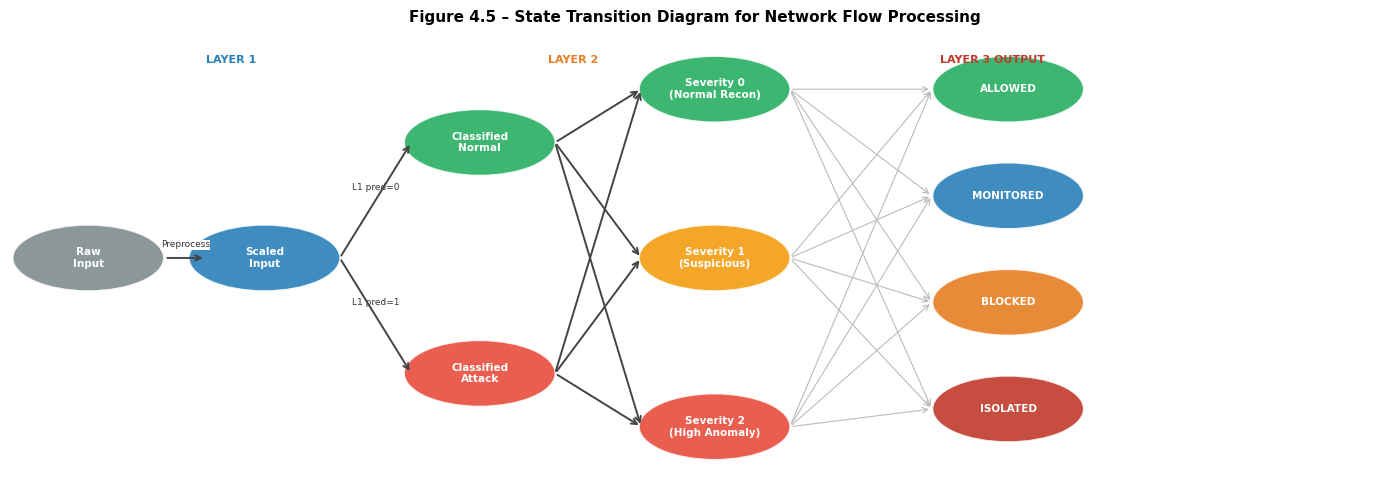

In [43]:
# ============================================================
# FIGURE 4.5 – State Transition Diagram
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Ellipse

fig, ax = plt.subplots(figsize=(14,5))
ax.set_xlim(0,14); ax.set_ylim(0,5); ax.axis('off')

states = [
    (0.8, 2.5, 'Raw\nInput',        '#7F8C8D'),
    (2.6, 2.5, 'Scaled\nInput',     '#2980B9'),
    (4.8, 3.8, 'Classified\nNormal','#27AE60'),
    (4.8, 1.2, 'Classified\nAttack','#E74C3C'),
    (7.2, 4.4, 'Severity 0\n(Normal Recon)','#27AE60'),
    (7.2, 2.5, 'Severity 1\n(Suspicious)','#F39C12'),
    (7.2, 0.6, 'Severity 2\n(High Anomaly)','#E74C3C'),
    (10.2,4.4, 'ALLOWED',   '#27AE60'),
    (10.2,3.2, 'MONITORED', '#2980B9'),
    (10.2,2.0, 'BLOCKED',   '#E67E22'),
    (10.2,0.8, 'ISOLATED',  '#C0392B'),
]

for (x,y,lbl,col) in states:
    e = Ellipse((x,y),1.55,0.75,facecolor=col,
                edgecolor='white',lw=1.5,zorder=3,alpha=0.9)
    ax.add_patch(e)
    ax.text(x,y,lbl,ha='center',va='center',fontsize=7.5,
            fontweight='bold',color='white',zorder=4,multialignment='center')

def tarr(ax,x1,y1,x2,y2,lbl=''):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',color='#444',lw=1.4),zorder=5)
    if lbl:
        ax.text((x1+x2)/2,(y1+y2)/2+0.12,lbl,fontsize=6.5,
                ha='center',color='#333',
                bbox=dict(facecolor='white',edgecolor='none',pad=0.5))

tarr(ax,1.58,2.5,2.0,2.5,'Preprocess')
tarr(ax,3.37,2.5,4.1,3.8,'L1 pred=0')
tarr(ax,3.37,2.5,4.1,1.2,'L1 pred=1')
for sy in [4.4,2.5,0.6]:
    tarr(ax,5.57,3.8,6.45,sy)
    tarr(ax,5.57,1.2,6.45,sy)
for ty in [4.4,3.2,2.0,0.8]:
    for sy in [4.4,2.5,0.6]:
        ax.annotate('',xy=(9.42,ty),xytext=(7.97,sy),
                    arrowprops=dict(arrowstyle='->',color='#bbb',lw=0.8),zorder=2)

ax.text(2.0,4.7,'LAYER 1',fontsize=8,fontweight='bold',color='#2980B9')
ax.text(5.5,4.7,'LAYER 2',fontsize=8,fontweight='bold',color='#E67E22')
ax.text(9.5,4.7,'LAYER 3 OUTPUT',fontsize=8,fontweight='bold',color='#C0392B')

ax.set_title('Figure 4.5 – State Transition Diagram for Network Flow Processing',
             fontsize=11,fontweight='bold',pad=10)
plt.tight_layout()
plt.savefig('fig4_5_state.png',dpi=180,bbox_inches='tight')
plt.show()

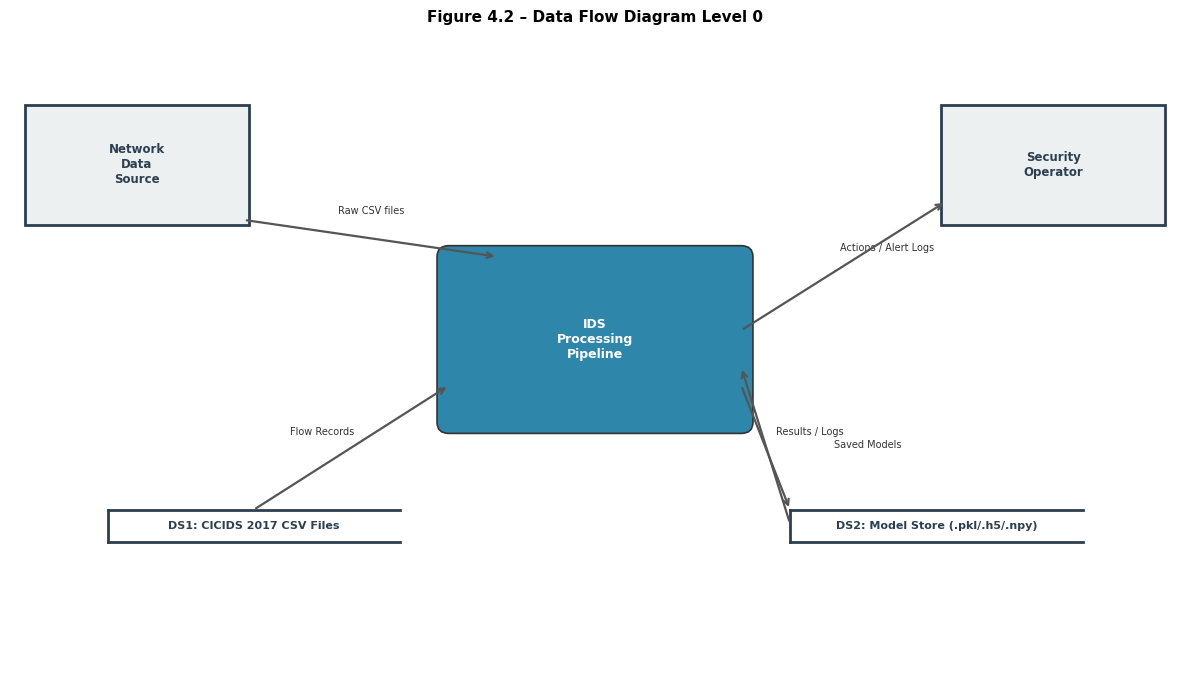

In [44]:
# ============================================================
# FIGURE 4.2 – Data Flow Diagram Level 0
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12); ax.set_ylim(0, 7); ax.axis('off')

def rect(ax, x, y, w, h, txt, color='#2E86AB', tcolor='white', fs=9):
    r = FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.12",
                       facecolor=color, edgecolor='#333', lw=1.2, zorder=3)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, txt, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=tcolor, zorder=4,
            multialignment='center')

def ext(ax, x, y, w, h, txt):   # external entity – rectangle no fill
    r = FancyBboxPatch((x,y), w, h, boxstyle="square,pad=0.05",
                       facecolor='#ECF0F1', edgecolor='#2C3E50', lw=2, zorder=3)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, txt, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='#2C3E50', zorder=4,
            multialignment='center')

def store(ax, x, y, w, txt):   # open-ended rectangle (data store)
    ax.plot([x, x+w], [y+0.35, y+0.35], color='#2C3E50', lw=2)
    ax.plot([x, x+w], [y,      y     ], color='#2C3E50', lw=2)
    ax.plot([x,     x    ], [y, y+0.35], color='#2C3E50', lw=2)
    ax.text(x+w/2, y+0.175, txt, ha='center', va='center',
            fontsize=8, color='#2C3E50', fontweight='bold')

def arr(ax, x1,y1,x2,y2, lbl='', lx=None, ly=None):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.6), zorder=5)
    if lbl:
        mx,my = (lx or (x1+x2)/2), (ly or (y1+y2)/2)
        ax.text(mx, my, lbl, fontsize=7, color='#333',
                ha='center', va='center',
                bbox=dict(facecolor='white', edgecolor='none', pad=1))

# External entities
ext(ax, 0.2, 5.0, 2.2, 1.2, 'Network\nData\nSource')
ext(ax, 9.6, 5.0, 2.2, 1.2, 'Security\nOperator')

# Main process
rect(ax, 4.5, 2.8, 3.0, 1.8, 'IDS\nProcessing\nPipeline', '#2E86AB')

# Data stores
store(ax, 1.0, 1.5, 3.0, 'DS1: CICIDS 2017 CSV Files')
store(ax, 8.0, 1.5, 3.0, 'DS2: Model Store (.pkl/.h5/.npy)')

# Arrows
arr(ax, 2.4, 5.0, 5.0, 4.6,  'Raw CSV files', 3.7, 5.1)
arr(ax, 7.5, 3.8, 9.6, 5.2,  'Actions / Alert Logs', 9.0, 4.7)
arr(ax, 2.5, 1.85,4.5, 3.2,  'Flow Records', 3.2, 2.7)
arr(ax, 7.5, 3.2, 8.0, 1.85, 'Results / Logs', 8.2, 2.7)
arr(ax, 8.0, 1.7, 7.5, 3.4,  'Saved Models', 8.8, 2.55)

ax.set_title('Figure 4.2 – Data Flow Diagram Level 0',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig4_2_dfd0.png', dpi=180, bbox_inches='tight')
plt.show()

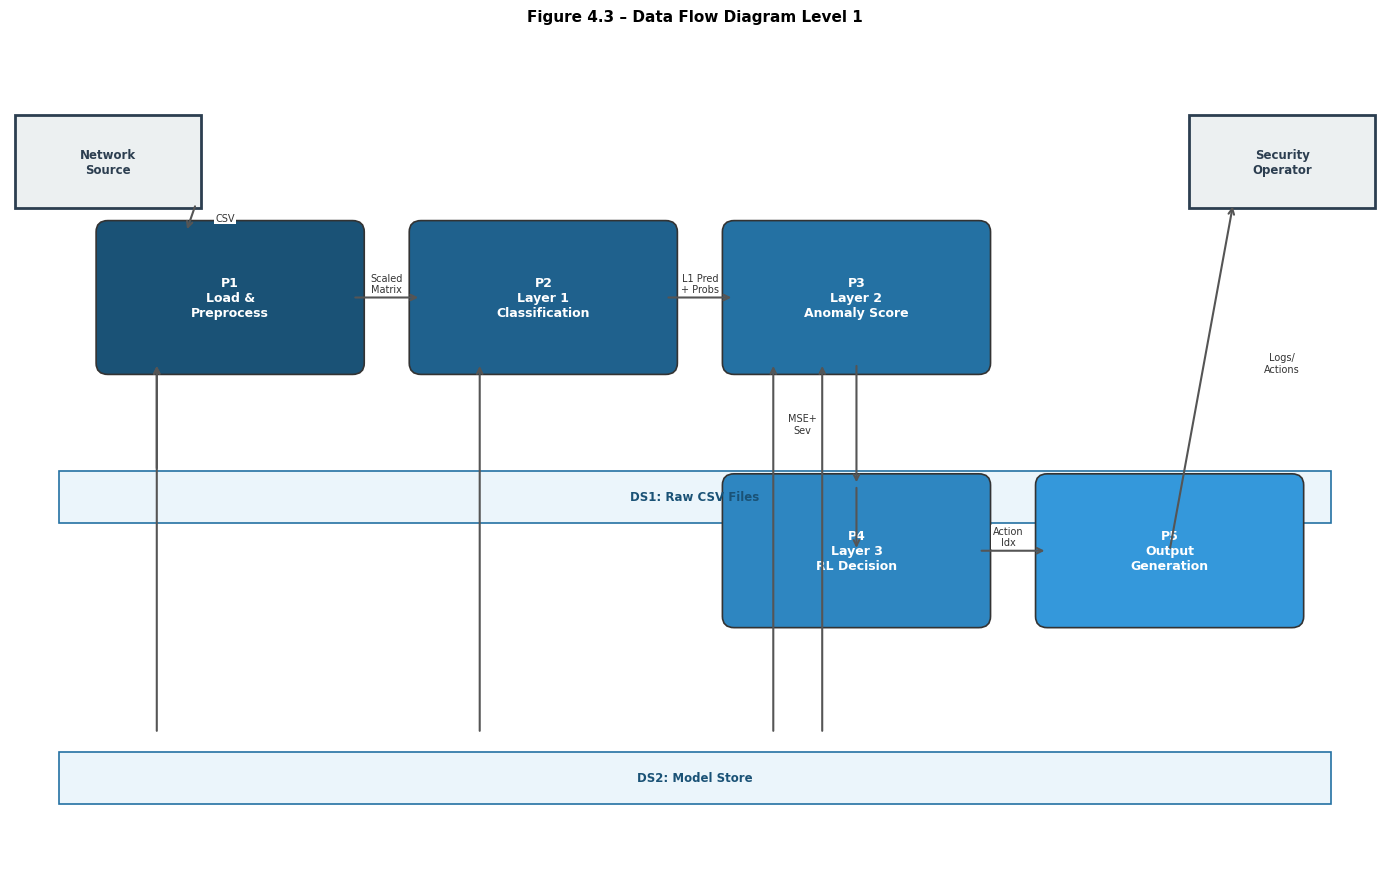

In [46]:
# ============================================================
# FIGURE 4.3 – Data Flow Diagram Level 1
# ============================================================
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0,14); ax.set_ylim(0,9); ax.axis('off')

colors = ['#1A5276','#1F618D','#2471A3','#2E86C1','#3498DB']
procs = [
    (1.0, 5.5, 2.5, 1.4, 'P1\nLoad &\nPreprocess'),
    (4.2, 5.5, 2.5, 1.4, 'P2\nLayer 1\nClassification'),
    (7.4, 5.5, 2.5, 1.4, 'P3\nLayer 2\nAnomaly Score'),
    (7.4, 2.8, 2.5, 1.4, 'P4\nLayer 3\nRL Decision'),
    (10.6,2.8, 2.5, 1.4, 'P5\nOutput\nGeneration'),
]
for i,(x,y,w,h,t) in enumerate(procs):
    rect(ax,x,y,w,h,t,colors[i])

# Stores (horizontal strips)
for y2, lbl in [(4.0,'DS1: Raw CSV Files'), (1.0,'DS2: Model Store')]:
    ax.add_patch(FancyBboxPatch((0.5,y2-0.2),13,0.55,
                 boxstyle="square,pad=0.0",
                 facecolor='#EBF5FB', edgecolor='#2471A3', lw=1.2))
    ax.text(7.0, y2+0.08, lbl, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='#1A5276')

# External
ext(ax, 0.1, 7.2, 1.8, 0.9, 'Network\nSource')
ext(ax, 12.1,7.2, 1.8, 0.9, 'Security\nOperator')

def darr(ax,x1,y1,x2,y2,lbl='',lbx=None,lby=None):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',color='#555',lw=1.5),zorder=5)
    if lbl:
        ax.text(lbx or (x1+x2)/2, lby or (y1+y2)/2, lbl,
                fontsize=7,color='#333',ha='center',va='center',
                bbox=dict(facecolor='white',edgecolor='none',pad=1))

darr(ax,1.9,7.2,1.8,6.9,'CSV',2.2,7.05)
darr(ax,3.5,6.2,4.2,6.2,'Scaled\nMatrix',3.85,6.35)
darr(ax,6.7,6.2,7.4,6.2,'L1 Pred\n+ Probs',7.05,6.35)
darr(ax,8.65,5.5,8.65,4.2,'MSE+\nSev',8.1,4.85)
darr(ax,8.65,4.2,8.65,3.5,)
darr(ax,9.9,3.5,10.6,3.5,'Action\nIdx',10.2,3.65)
darr(ax,11.85,3.5,12.5,7.2,'Logs/\nActions',13.0,5.5)
# model store reads
for xp in [1.5, 4.8, 7.8, 8.3]:
    darr(ax, xp, 1.55, xp, 5.5)
# csv read
darr(ax,1.5,4.35,1.5,5.5)

ax.set_title('Figure 4.3 – Data Flow Diagram Level 1',
             fontsize=11,fontweight='bold',pad=10)
plt.tight_layout()
plt.savefig('fig4_3_dfd1.png', dpi=180, bbox_inches='tight')
plt.show()

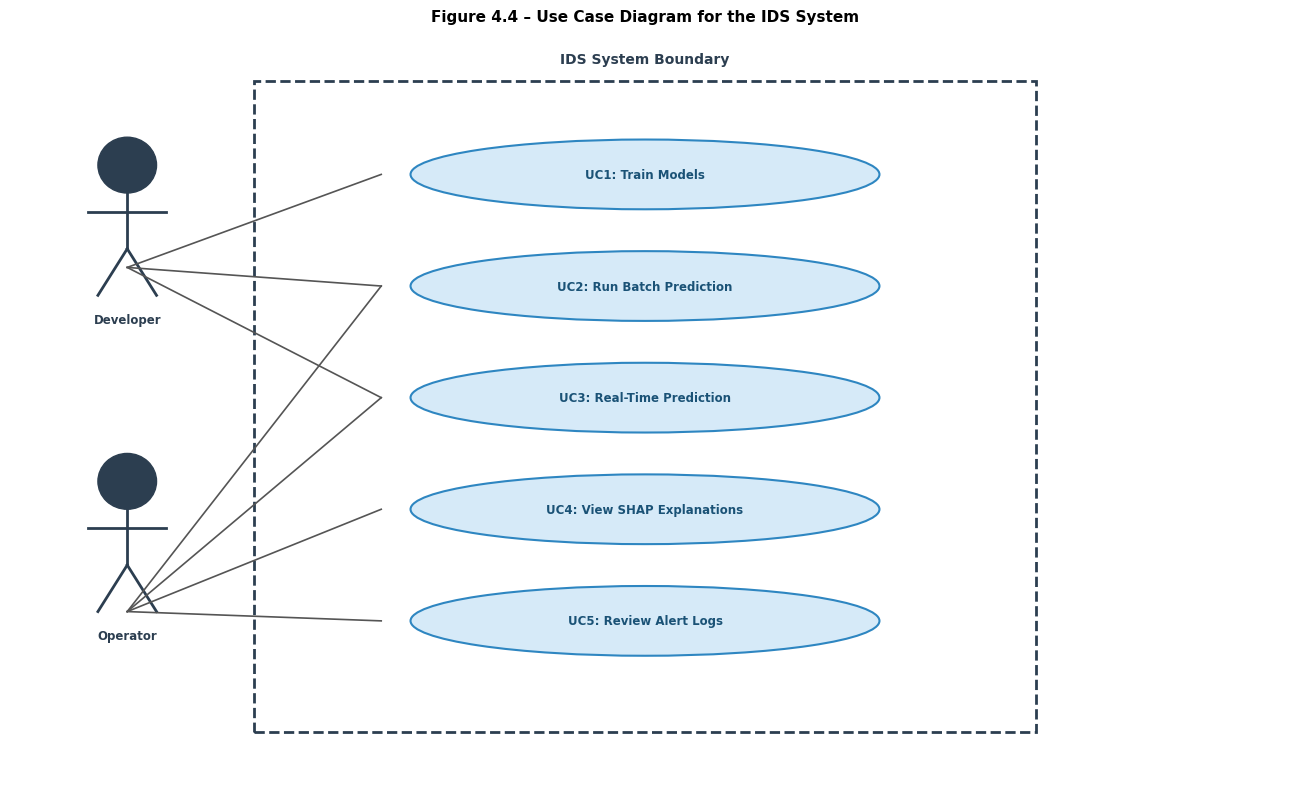

In [47]:
# ============================================================
# FIGURE 4.4 – Use Case Diagram
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(13,8))
ax.set_xlim(0,13); ax.set_ylim(0,8); ax.axis('off')

# System boundary
sys_rect = plt.Rectangle((2.5,0.5),8,7,
                          fill=False,edgecolor='#2C3E50',lw=2,linestyle='--')
ax.add_patch(sys_rect)
ax.text(6.5,7.7,'IDS System Boundary',ha='center',fontsize=10,
        fontweight='bold',color='#2C3E50')

# Actors (stick figures simplified as labelled circles)
def actor(ax,x,y,name):
    c = plt.Circle((x,y+0.4),0.3,color='#2C3E50',zorder=3)
    ax.add_patch(c)
    ax.plot([x,x],[y+0.1,y-0.5],color='#2C3E50',lw=2)
    ax.plot([x-0.4,x+0.4],[y-0.1,y-0.1],color='#2C3E50',lw=2)
    ax.plot([x,x-0.3],[y-0.5,y-1.0],color='#2C3E50',lw=2)
    ax.plot([x,x+0.3],[y-0.5,y-1.0],color='#2C3E50',lw=2)
    ax.text(x,y-1.3,name,ha='center',fontsize=8.5,fontweight='bold',color='#2C3E50')

actor(ax,1.2,6.2,'Developer')
actor(ax,1.2,2.8,'Operator')

# Use cases
uc_positions = [
    (6.5,6.5,'UC1: Train Models'),
    (6.5,5.3,'UC2: Run Batch Prediction'),
    (6.5,4.1,'UC3: Real-Time Prediction'),
    (6.5,2.9,'UC4: View SHAP Explanations'),
    (6.5,1.7,'UC5: Review Alert Logs'),
]
for (x,y,lbl) in uc_positions:
    e = Ellipse((x,y),4.8,0.75,facecolor='#D6EAF8',
                edgecolor='#2E86C1',lw=1.5,zorder=3)
    ax.add_patch(e)
    ax.text(x,y,lbl,ha='center',va='center',fontsize=8.5,
            fontweight='bold',color='#1A5276',zorder=4)

# Association lines
for uc in [6.5,5.3,4.1]:
    ax.plot([1.2,3.8],[5.5,uc],'#555',lw=1.2)
for uc in [5.3,4.1,2.9,1.7]:
    ax.plot([1.2,3.8],[1.8,uc],'#555',lw=1.2)

ax.set_title('Figure 4.4 – Use Case Diagram for the IDS System',
             fontsize=11,fontweight='bold',pad=10)
plt.tight_layout()
plt.savefig('fig4_4_usecase.png',dpi=180,bbox_inches='tight')
plt.show()

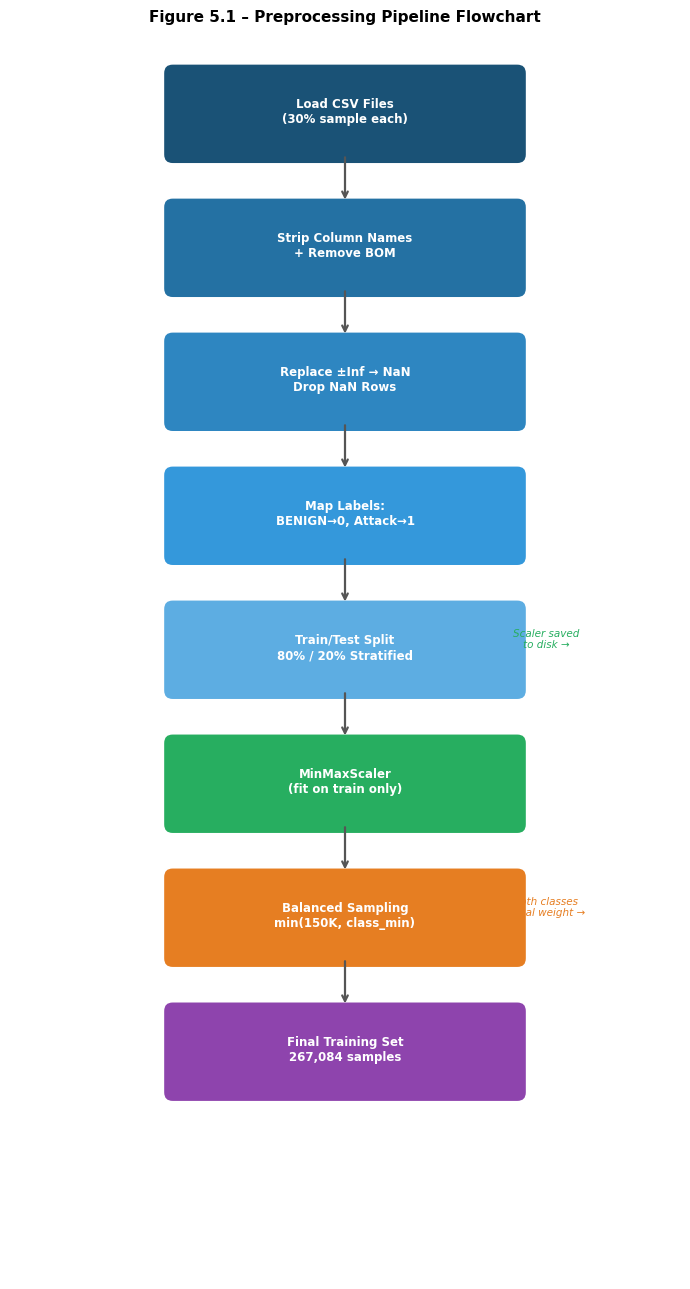

In [48]:
# ============================================================
# FIGURE 5.1 – Preprocessing Pipeline Flowchart
# ============================================================
fig, ax = plt.subplots(figsize=(7,13))
ax.set_xlim(0,7); ax.set_ylim(0,13); ax.axis('off')

steps = [
    (3.5,12.2,'Load CSV Files\n(30% sample each)','#1A5276','rect'),
    (3.5,10.8,'Strip Column Names\n+ Remove BOM','#2471A3','rect'),
    (3.5, 9.4,'Replace ±Inf → NaN\nDrop NaN Rows','#2E86C1','rect'),
    (3.5, 8.0,'Map Labels:\nBENIGN→0, Attack→1','#3498DB','rect'),
    (3.5, 6.6,'Train/Test Split\n80% / 20% Stratified','#5DADE2','rect'),
    (3.5, 5.2,'MinMaxScaler\n(fit on train only)','#27AE60','rect'),
    (3.5, 3.8,'Balanced Sampling\nmin(150K, class_min)','#E67E22','rect'),
    (3.5, 2.4,'Final Training Set\n267,084 samples','#8E44AD','rect'),
]

for (x,y,lbl,col,_) in steps:
    r = FancyBboxPatch((x-1.8, y-0.45), 3.6, 0.85,
                       boxstyle="round,pad=0.1",
                       facecolor=col, edgecolor='white', lw=1.5, zorder=3)
    ax.add_patch(r)
    ax.text(x, y, lbl, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white',
            zorder=4, multialignment='center')

# Arrows between steps
for i in range(len(steps)-1):
    y1 = steps[i][1] - 0.45
    y2 = steps[i+1][1] + 0.45
    ax.annotate('', xy=(3.5,y2), xytext=(3.5,y1),
                arrowprops=dict(arrowstyle='->',color='#555',lw=1.6), zorder=5)

# Decision diamond for split
ax.text(5.6, 6.6, 'Scaler saved\nto disk →', fontsize=7.5, color='#27AE60',
        ha='center', style='italic')
ax.text(5.6, 3.8, 'Both classes\nequal weight →', fontsize=7.5, color='#E67E22',
        ha='center', style='italic')

ax.set_title('Figure 5.1 – Preprocessing Pipeline Flowchart',
             fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig5_1_preprocess.png', dpi=180, bbox_inches='tight')
plt.show()

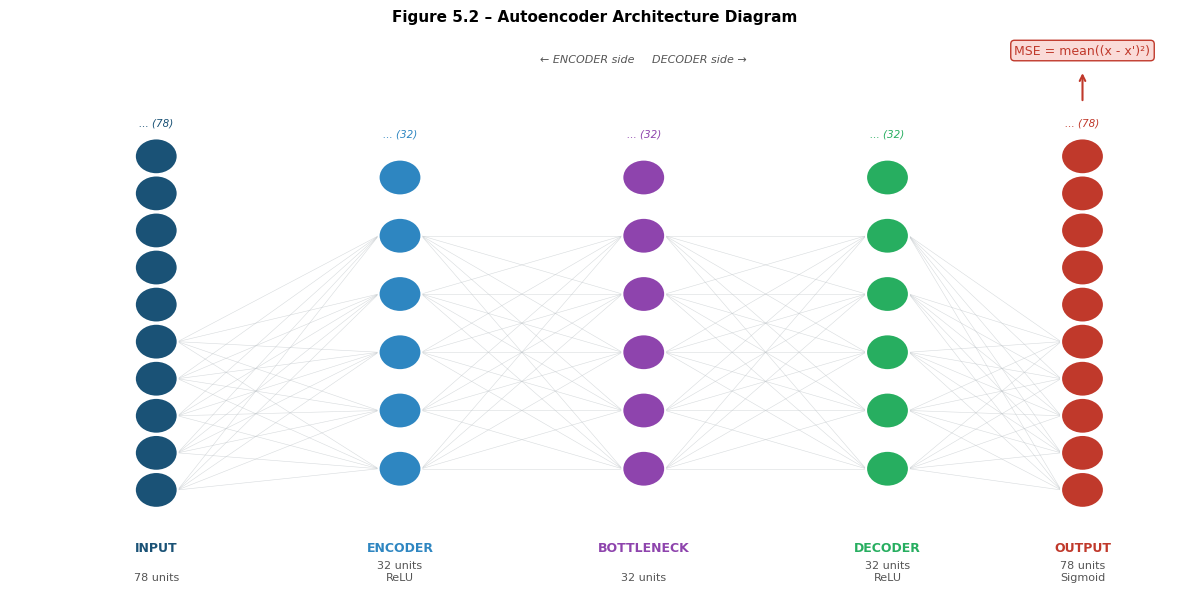

In [50]:
# ============================================================
# FIGURE 5.2 – Autoencoder Architecture Diagram
# ============================================================
import numpy as np

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlim(0,12); ax.set_ylim(0,6); ax.axis('off')

def draw_layer(ax, x, n_shown, total, color, label, sublabel):
    spacing = 5.0 / (n_shown+1)
    for i in range(n_shown):
        y = spacing*(i+1)
        c = plt.Circle((x, y), 0.22, color=color,
                        zorder=3, ec='white', lw=1.5)
        ax.add_patch(c)
    if total > n_shown:
        ax.text(x, spacing*(n_shown+0.5)+0.15, f'... ({total})',
                ha='center', fontsize=7.5, color=color, style='italic')
    ax.text(x, -0.3, label, ha='center', fontsize=9,
            fontweight='bold', color=color)
    ax.text(x, -0.65, sublabel, ha='center', fontsize=8, color='#555')
    return spacing

layers = [
    (1.5,  10, 78,  '#1A5276', 'INPUT',   '78 units'),
    (4.0,   6, 32,  '#2E86C1', 'ENCODER', '32 units\nReLU'),
    (6.5,   6, 32,  '#8E44AD', 'BOTTLENECK','32 units'),
    (9.0,   6, 32,  '#27AE60', 'DECODER', '32 units\nReLU'),
    (11.0, 10, 78,  '#C0392B', 'OUTPUT',  '78 units\nSigmoid'),
]

node_positions = {}
for (x, ns, tot, col, lbl, sub) in layers:
    sp = draw_layer(ax, x, ns, tot, col, lbl, sub)
    node_positions[lbl] = (x, [sp*(i+1) for i in range(ns)])

# Connection lines between adjacent layers (sample connections)
layer_list = [l[0] for l in layers]
col_list   = [l[3] for l in layers]
lbl_list   = [l[4] for l in layers]

for li in range(len(layers)-1):
    x1 = layers[li][0]
    x2 = layers[li+1][0]
    ys1_data = node_positions[lbl_list[li]][1] # Get the list of y-coordinates
    ys2_data = node_positions[lbl_list[li+1]][1] # Get the list of y-coordinates
    for y1 in ys1_data[:5]:
        for y2 in ys2_data[:5]:
            ax.plot([x1+0.22, x2-0.22], [y1, y2],
                    color='#BDC3C7', lw=0.4, alpha=0.6, zorder=1)

# MSE annotation
ax.annotate('MSE = mean((x - x\')²)',
            xy=(11.0,5.8), fontsize=9, color='#C0392B',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#FADBD8', edgecolor='#C0392B'))
ax.annotate('', xy=(11.0, 5.6), xytext=(11.0, 5.2),
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))
ax.text(6.5, 5.7, '← ENCODER side     DECODER side →',
        ha='center', fontsize=8, color='#555', style='italic')

ax.set_title('Figure 5.2 – Autoencoder Architecture Diagram',
             fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig5_2_autoencoder.png', dpi=180, bbox_inches='tight')
plt.show()

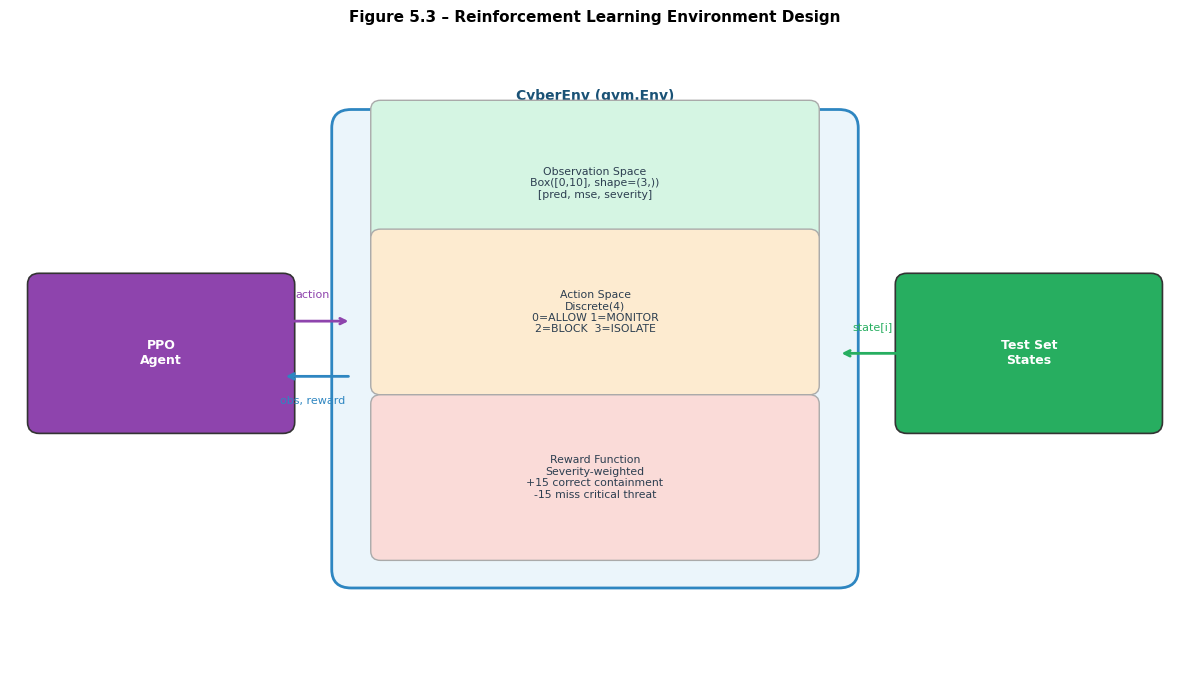

In [51]:
# ============================================================
# FIGURE 5.3 – RL Environment Design
# ============================================================
fig, ax = plt.subplots(figsize=(12,7))
ax.set_xlim(0,12); ax.set_ylim(0,7); ax.axis('off')

# Environment box
env = FancyBboxPatch((3.5,1.2),5,4.8,boxstyle="round,pad=0.2",
                     facecolor='#EBF5FB',edgecolor='#2E86C1',lw=2,zorder=1)
ax.add_patch(env)
ax.text(6.0,6.3,'CyberEnv (gym.Env)',ha='center',fontsize=10,
        fontweight='bold',color='#1A5276')

# Inside env – observation/action/reward
for y2,col,lbl in [(5.2,'#D5F5E3','Observation Space\nBox([0,10], shape=(3,))\n[pred, mse, severity]'),
                   (3.8,'#FDEBD0','Action Space\nDiscrete(4)\n0=ALLOW 1=MONITOR\n2=BLOCK  3=ISOLATE'),
                   (2.0,'#FADBD8','Reward Function\nSeverity-weighted\n+15 correct containment\n-15 miss critical threat')]:
    r = FancyBboxPatch((3.8,y2-0.6),4.4,1.6,boxstyle="round,pad=0.1",
                       facecolor=col,edgecolor='#AAA',lw=1,zorder=3)
    ax.add_patch(r)
    ax.text(6.0,y2+0.2,lbl,ha='center',va='center',fontsize=7.8,
            color='#2C3E50',zorder=4,multialignment='center')

# PPO Agent box
rect(ax,0.3,2.8,2.5,1.5,'PPO\nAgent','#8E44AD')
# Data box
rect(ax,9.2,2.8,2.5,1.5,'Test Set\nStates','#27AE60')

# Arrows
ax.annotate('',xy=(3.5,3.9),xytext=(2.8,3.9),
            arrowprops=dict(arrowstyle='->',color='#8E44AD',lw=2),zorder=5)
ax.text(3.1,4.15,'action',fontsize=8,color='#8E44AD',ha='center')
ax.annotate('',xy=(2.8,3.3),xytext=(3.5,3.3),
            arrowprops=dict(arrowstyle='->',color='#2E86C1',lw=2),zorder=5)
ax.text(3.1,3.0,'obs, reward',fontsize=8,color='#2E86C1',ha='center')
ax.annotate('',xy=(8.5,3.55),xytext=(9.2,3.55),
            arrowprops=dict(arrowstyle='->',color='#27AE60',lw=2),zorder=5)
ax.text(8.85,3.8,'state[i]',fontsize=8,color='#27AE60',ha='center')

ax.set_title('Figure 5.3 – Reinforcement Learning Environment Design',
             fontsize=11,fontweight='bold',pad=10)
plt.tight_layout()
plt.savefig('fig5_3_rl_env.png',dpi=180,bbox_inches='tight')
plt.show()

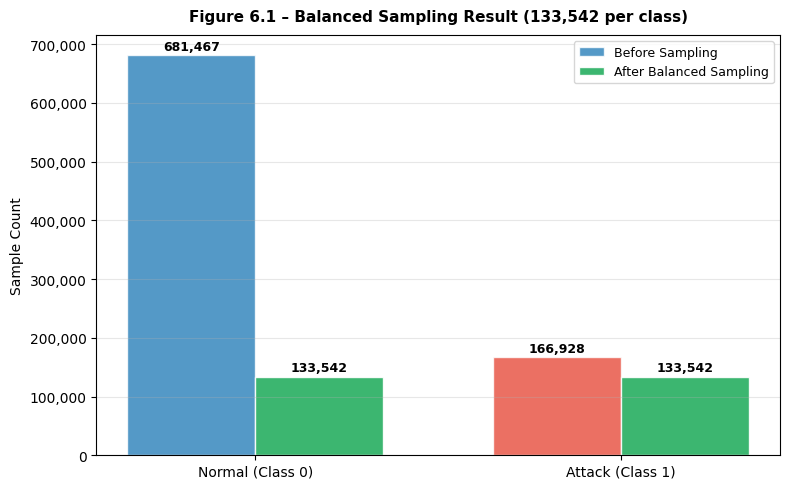

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [52]:
# ============================================================
# FIGURE 6.1 – Balanced Sampling Result
# (Run AFTER balanced sampling cell in your notebook)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

labels = ['Normal (Class 0)', 'Attack (Class 1)']
before = [681467, 166928]
after  = [133542, 133542]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x - w/2, before, w, label='Before Sampling',
            color=['#2980B9','#E74C3C'], alpha=0.8, edgecolor='white')
b2 = ax.bar(x + w/2, after, w, label='After Balanced Sampling',
            color=['#27AE60','#27AE60'], alpha=0.9, edgecolor='white')

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+4000,
            f'{bar.get_height():,}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Sample Count', fontsize=10)
ax.set_title('Figure 6.1 – Balanced Sampling Result (133,542 per class)',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_1_sampling.png', dpi=180, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

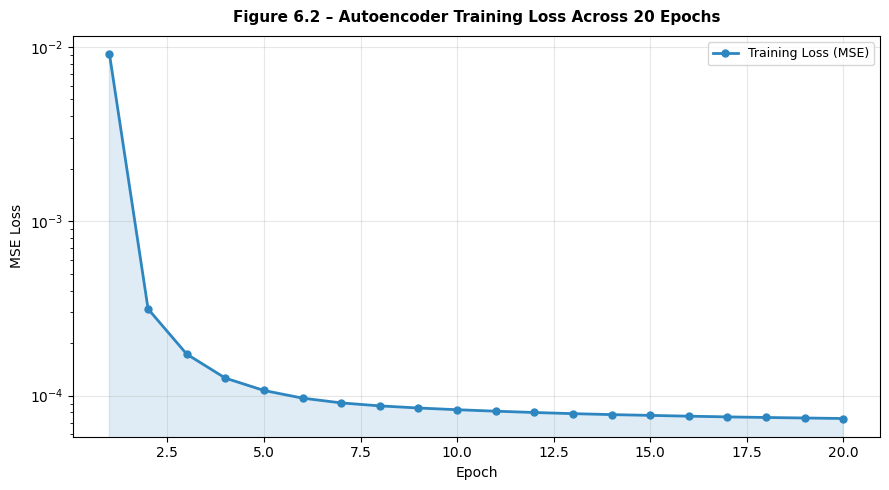

In [53]:
# ============================================================
# FIGURE 6.2 – Autoencoder Training Loss
# (Run AFTER autoencoder.fit() – pass history object)
# history = autoencoder.fit(...)
# ============================================================
epochs = range(1, 21)
# Replace with:  loss = history.history['loss']
loss = [0.0091,0.000314,0.000173,0.000126,0.000107,
        0.0000967,0.0000908,0.0000873,0.0000849,0.0000830,
        0.0000814,0.0000800,0.0000788,0.0000778,0.0000770,
        0.0000762,0.0000755,0.0000749,0.0000744,0.0000739]

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(epochs, loss, 'o-', color='#2E86C1', lw=2, ms=5, label='Training Loss (MSE)')
ax.fill_between(epochs, loss, alpha=0.15, color='#2E86C1')
ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('MSE Loss', fontsize=10)
ax.set_title('Figure 6.2 – Autoencoder Training Loss Across 20 Epochs',
             fontsize=11, fontweight='bold', pad=10)
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig6_2_ae_loss.png', dpi=180, bbox_inches='tight')
plt.show()

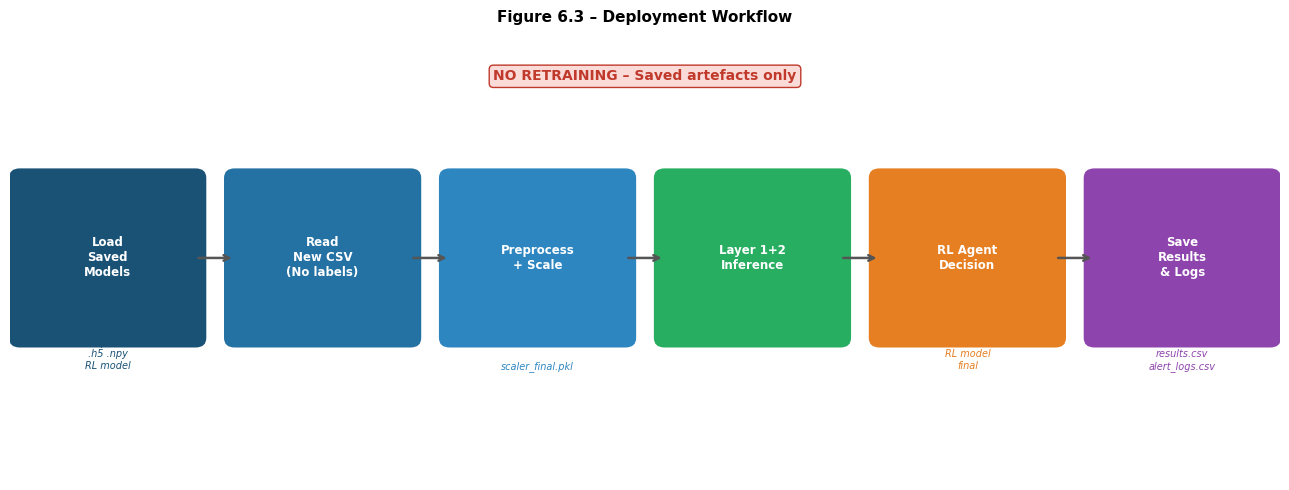

In [54]:
# ============================================================
# FIGURE 6.3 – Deployment Workflow
# ============================================================
fig, ax = plt.subplots(figsize=(13,5))
ax.set_xlim(0,13); ax.set_ylim(0,5); ax.axis('off')

steps = [
    (1.0, 2.5, 'Load\nSaved\nModels',        '#1A5276'),
    (3.2, 2.5, 'Read\nNew CSV\n(No labels)',  '#2471A3'),
    (5.4, 2.5, 'Preprocess\n+ Scale',        '#2E86C1'),
    (7.6, 2.5, 'Layer 1+2\nInference',       '#27AE60'),
    (9.8, 2.5, 'RL Agent\nDecision',         '#E67E22'),
    (12.0,2.5, 'Save\nResults\n& Logs',       '#8E44AD'),
]
for (x,y,lbl,col) in steps:
    r = FancyBboxPatch((x-0.9,y-0.9),1.8,1.8,
                       boxstyle="round,pad=0.12",
                       facecolor=col,edgecolor='white',lw=1.5,zorder=3)
    ax.add_patch(r)
    ax.text(x,y,lbl,ha='center',va='center',fontsize=8.5,
            fontweight='bold',color='white',zorder=4,multialignment='center')

for i in range(len(steps)-1):
    ax.annotate('',xy=(steps[i+1][0]-0.9, steps[i+1][1]),
                xytext=(steps[i][0]+0.9, steps[i][1]),
                arrowprops=dict(arrowstyle='->',color='#555',lw=1.8),zorder=5)

# File labels below
files = ['.pkl\n.h5 .npy\nRL model','','scaler_final.pkl','','RL model\nfinal','results.csv\nalert_logs.csv']
for i,(x,y,_,col) in enumerate(steps):
    if files[i]:
        ax.text(x,y-1.25,files[i],ha='center',fontsize=7,
                color=col,style='italic',multialignment='center')

ax.text(6.5,4.5,'NO RETRAINING – Saved artefacts only',
        ha='center',fontsize=10,fontweight='bold',color='#C0392B',
        bbox=dict(facecolor='#FADBD8',edgecolor='#C0392B',
                  boxstyle='round,pad=0.3'))

ax.set_title('Figure 6.3 – Deployment Workflow',
             fontsize=11,fontweight='bold',pad=10)
plt.tight_layout()
plt.savefig('fig6_3_deploy.png',dpi=180,bbox_inches='tight')
plt.show()

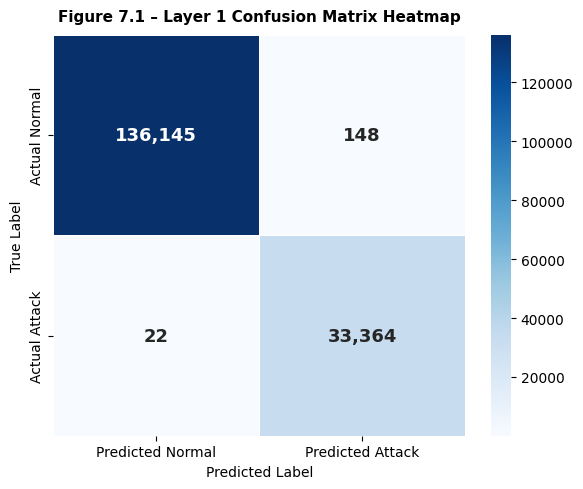

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [55]:
# ============================================================
# FIGURE 7.1 – Layer 1 Confusion Matrix Heatmap
# (Run AFTER stacking evaluation cell)
# Replace cm with your actual confusion matrix variable
# ============================================================
import seaborn as sns
import numpy as np

cm = np.array([[136145, 148],
               [22,     33364]])

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Predicted Normal','Predicted Attack'],
            yticklabels=['Actual Normal','Actual Attack'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size':13,'fontweight':'bold'}, ax=ax)
ax.set_title('Figure 7.1 – Layer 1 Confusion Matrix Heatmap',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.savefig('fig7_1_cm.png', dpi=180, bbox_inches='tight')
plt.show()

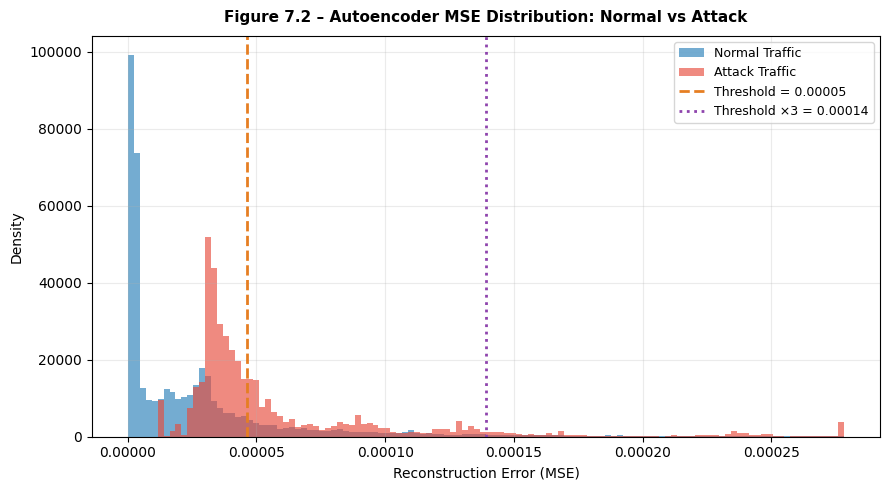

In [56]:
# ============================================================
# FIGURE 7.2 – Autoencoder MSE Distribution
# (Run AFTER mse and y_test are defined)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9,5))
# Replace mse and y_test with your actual variables
normal_mse = mse[y_test == 0]
attack_mse = mse[y_test == 1]

ax.hist(normal_mse, bins=120, alpha=0.65, color='#2980B9',
        label='Normal Traffic', density=True, range=(0, threshold*6))
ax.hist(attack_mse, bins=120, alpha=0.65, color='#E74C3C',
        label='Attack Traffic', density=True, range=(0, threshold*6))
ax.axvline(threshold, color='#E67E22', lw=2, linestyle='--',
           label=f'Threshold = {threshold:.5f}')
ax.axvline(threshold*3, color='#8E44AD', lw=2, linestyle=':',
           label=f'Threshold ×3 = {threshold*3:.5f}')
ax.set_xlabel('Reconstruction Error (MSE)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Figure 7.2 – Autoencoder MSE Distribution: Normal vs Attack',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('fig7_2_mse_dist.png', dpi=180, bbox_inches='tight')
plt.show()

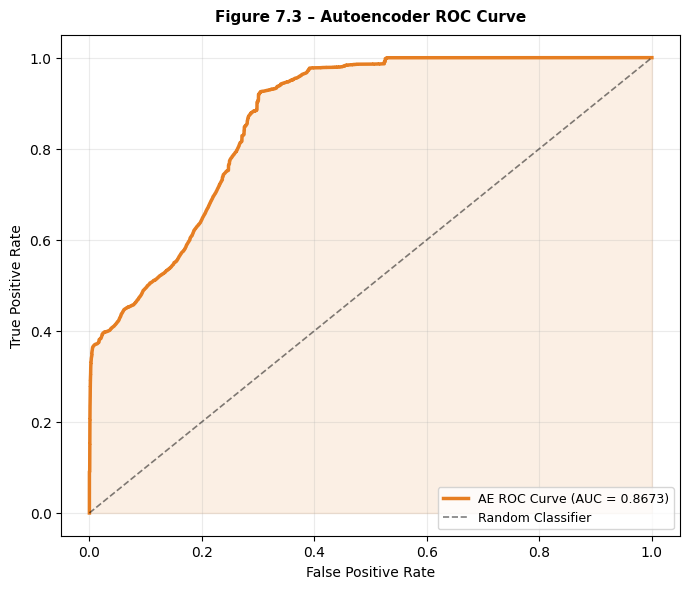

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [57]:
# ============================================================
# FIGURE 7.3 – Autoencoder ROC Curve
# (Run AFTER mse and y_test are defined)
# ============================================================
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, mse)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr, tpr, color='#E67E22', lw=2.5,
        label=f'AE ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.2, alpha=0.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.12, color='#E67E22')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate', fontsize=10)
ax.set_title('Figure 7.3 – Autoencoder ROC Curve',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('fig7_3_roc.png', dpi=180, bbox_inches='tight')
plt.show()

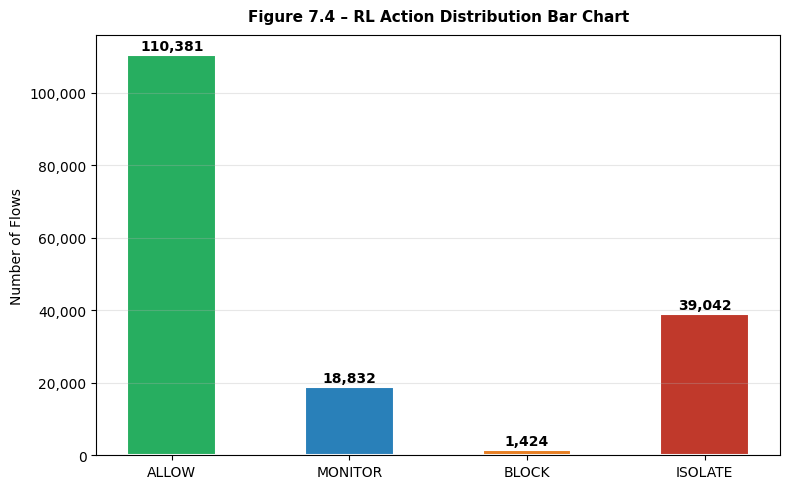

In [58]:
# ============================================================
# FIGURE 7.4 – RL Action Distribution Bar Chart
# (Run AFTER final_actions / results list is defined)
# ============================================================
from collections import Counter
import matplotlib.pyplot as plt

action_counts = Counter(final_actions)   # replace with your variable
actions = ['ALLOW','MONITOR','BLOCK','ISOLATE']
counts  = [action_counts.get(a,0) for a in actions]
colors  = ['#27AE60','#2980B9','#E67E22','#C0392B']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(actions, counts, color=colors, edgecolor='white',
              linewidth=1.5, width=0.5)
for bar,cnt in zip(bars,counts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+500,
            f'{cnt:,}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Flows', fontsize=10)
ax.set_title('Figure 7.4 – RL Action Distribution Bar Chart',
             fontsize=11, fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f'{int(v):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_4_action_dist.png', dpi=180, bbox_inches='tight')
plt.show()

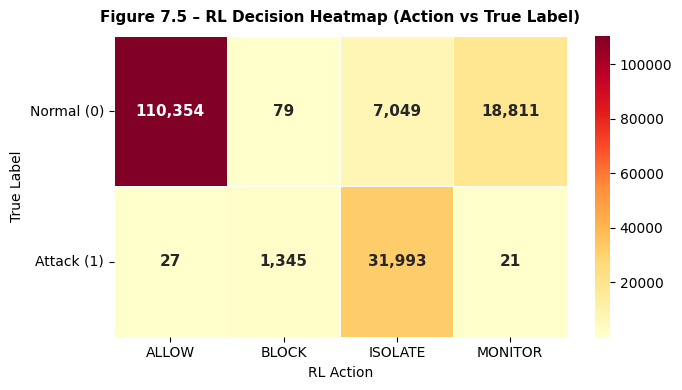

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [59]:
# ============================================================
# FIGURE 7.5 – RL Decision Heatmap
# (Run AFTER df_rl crosstab is defined)
# ============================================================
import pandas as pd, seaborn as sns

# Replace with your actual df_rl
crosstab = pd.crosstab(df_rl['True_Label'], df_rl['Action'])

fig, ax = plt.subplots(figsize=(7,4))
sns.heatmap(crosstab, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size':11,'fontweight':'bold'}, ax=ax)
ax.set_xticklabels(['ALLOW','BLOCK','ISOLATE','MONITOR'], fontsize=10)
ax.set_yticklabels(['Normal (0)','Attack (1)'], fontsize=10, rotation=0)
ax.set_title('Figure 7.5 – RL Decision Heatmap (Action vs True Label)',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('RL Action', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.savefig('fig7_5_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

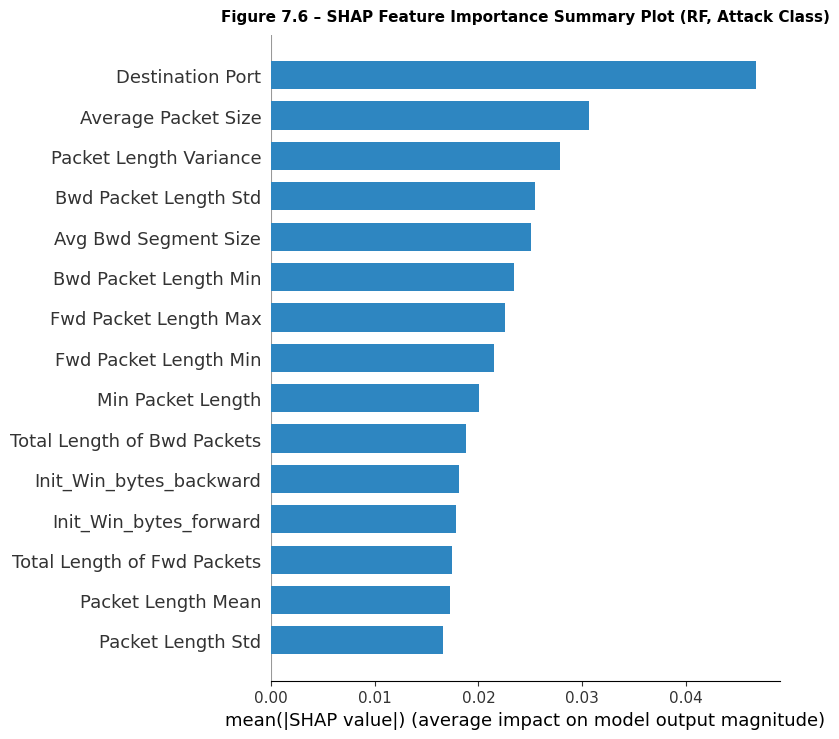

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [64]:
# ============================================================
# FIGURE 7.6 – SHAP Feature Importance
# (Run AFTER shap_values are computed)
# ============================================================
import shap, matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported if not already

# Replace with your actual rf, X_test, feature names
explainer   = shap.TreeExplainer(rf)

# Retrieve feature names from the original DataFrame X
feature_names = X.columns.tolist()

X_sample    = pd.DataFrame(X_test[:100], columns=feature_names)
shap_values = explainer.shap_values(X_sample)

# Correctly access SHAP values for class 1 (attack class)
# shap_values from TreeExplainer can be returned as a list of arrays (one per class)
# or a single 3D array (samples, features, classes), depending on SHAP version/model.
# The error suggests it might be the latter, and shap_values[1] was incorrectly indexing a sample.
if isinstance(shap_values, list):
    # This is the common output when shap_values returns a list of arrays, one for each class
    shap_values_for_plot = shap_values[1] # Get SHAP values for the positive class (index 1)
else:
    # If shap_values is a single 3D numpy array, assume its shape is (num_samples, num_features, num_classes)
    # and we need to slice for the specific class (index 1 for the second class).
    # This yields an array of shape (num_samples, num_features).
    shap_values_for_plot = shap_values[:, :, 1] # Select SHAP values for the second class across all samples and features

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_for_plot, X_sample, # X_sample (DataFrame) is used here as `features` for labels
                  plot_type='bar',
                  max_display=15,
                  show=False,
                  color='#2E86C1')
plt.title('Figure 7.6 – SHAP Feature Importance Summary Plot (RF, Attack Class)',
          fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig7_6_shap.png', dpi=180, bbox_inches='tight')
plt.show()

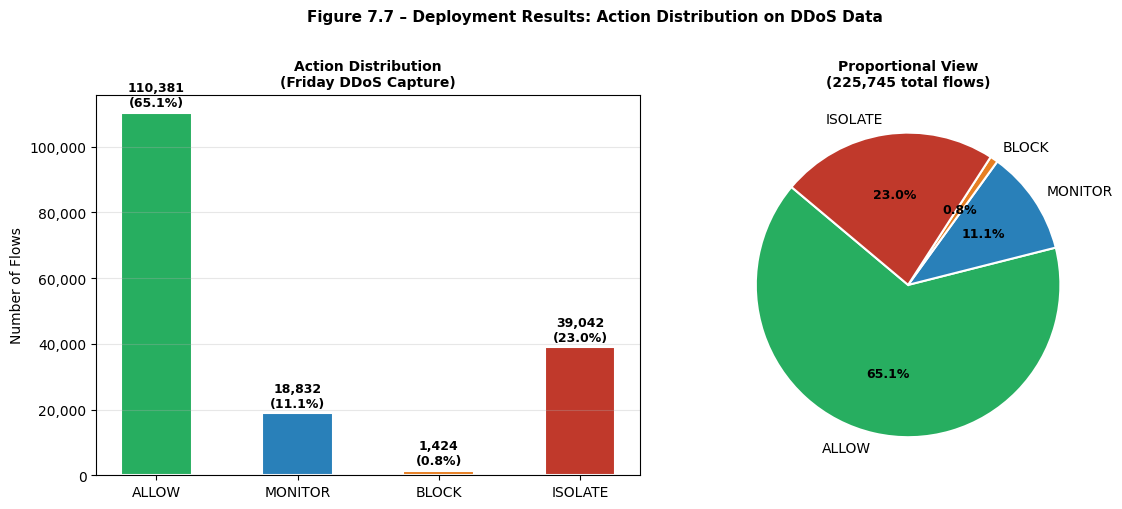

In [66]:
# ============================================================
# FIGURE 7.7 – Deployment Results Action Distribution
# (Run AFTER deployment batch prediction)
# ============================================================
from collections import Counter
import matplotlib.pyplot as plt

# Replace with your deployment results variable
deploy_counts = Counter(final_actions)
actions = ['ALLOW','MONITOR','BLOCK','ISOLATE']
counts  = [deploy_counts.get(a,0) for a in actions]
colors  = ['#27AE60','#2980B9','#E67E22','#C0392B']
total   = sum(counts)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

# Bar
bars = ax1.bar(actions, counts, color=colors, edgecolor='white',
               linewidth=1.5, width=0.5)
for bar,cnt in zip(bars,counts):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1000,
             f'{cnt:,}\n({cnt/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylabel('Number of Flows', fontsize=10)
ax1.set_title('Action Distribution\n(Friday DDoS Capture)', fontsize=10, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f'{int(v):,}'))
ax1.grid(axis='y', alpha=0.3)

# Pie
wedges,texts,autotexts = ax2.pie(
    counts, labels=actions, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold')
ax2.set_title('Proportional View\n(225,745 total flows)', fontsize=10, fontweight='bold')

fig.suptitle('Figure 7.7 – Deployment Results: Action Distribution on DDoS Data',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_7_deploy_results.png', dpi=180, bbox_inches='tight')
plt.show()